In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import TargetEncoder

from scipy import stats
import math

## Single Decision Trees

### tree with 'problem' feature

In [246]:
df_final = pd.read_csv('final_data.csv')
df_final2 = pd.read_csv('final_data_2.csv')
df_final.head()

,Unnamed: 0,ForceType,Sex,Race,TypeOfResistance,Problem_Group,CenterLongitude,CenterLatitude
0,0,Bodily Force,Female,Black,tensed,Violent,-93.298111,45.015878
1,1,Bodily Force,Male,Black,fled,Suspicious & Disorder,-93.225106,44.898115
2,2,Bodily Force,Male,Black,verbal non-compliance,Suspicious & Disorder,-93.269582,44.962688
3,3,Less Lethal Weapons,Male,White,tensed,Welfare & Emergency,-93.204183,44.906432
4,4,Bodily Force,Male,White,verbal non-compliance,Violent,-93.306312,44.979777


In [ ]:
X = df_final.drop(columns = ['ForceType', 'CenterLatitude', 'CenterLongitude', 'Unnamed: 0'])
y = df_final['ForceType']
X.head()

,Sex,Race,TypeOfResistance,Problem_Group
0,Female,Black,tensed,Violent
1,Male,Black,fled,Suspicious & Disorder
2,Male,Black,verbal non-compliance,Suspicious & Disorder
3,Male,White,tensed,Welfare & Emergency
4,Male,White,verbal non-compliance,Violent


In [248]:
# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23436, 18), (5860, 18), (23436,), (5860,))

In [249]:
X_train.head()

,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
7193,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
15903,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
14323,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
21947,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11094,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


In [250]:
# function for tree/forest evaluation
def eval_tree(y_true, y_pred):
    'calculating F1, accuracy, precision, and recall on a given model'

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title("Police Violence: Confusion Matrix")
    plt.show()

    accuracy = accuracy_score(y_true, y_pred)
    print(f'accuracy: {accuracy}')
    report = classification_report(y_true, y_pred, digits=4)
    print(report)

def bce_loss(y_true, f_hat, eps=1e-12):
    """
    Binary cross-entropy / log-loss (average over samples).
    y_true in {0,1}, f_hat in (0,1).
    """
    y_true = np.asarray(y_true).reshape(-1)
    f_hat = np.asarray(f_hat).reshape(-1)
    f_hat = np.clip(f_hat, eps, 1 - eps) # this handles edge cases so we don't do log(0) or something silly
    return -np.mean(y_true * np.log(f_hat) + (1 - y_true) * np.log(1 - f_hat))

# Small plotting helper to make a grid on the plot
def add_grid(ax=None):
    """Light grid for quick plots."""
    if ax is None:
        ax = plt.gca()
    ax.grid(True, linestyle='--', alpha=0.3)
    return ax

Max-depth 3 Tree
training accuracy: 0.737284519542584


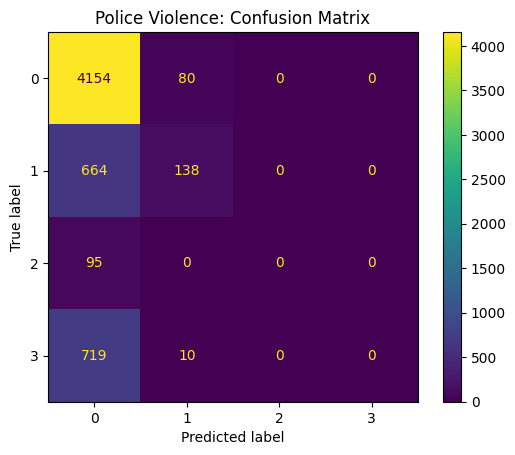

accuracy: 0.7324232081911263
                     precision    recall  f1-score   support

       Bodily Force     0.7376    0.9811    0.8421      4234
  Chemical Irritant     0.6053    0.1721    0.2680       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.0000    0.0000    0.0000       729

           accuracy                         0.7324      5860
          macro avg     0.3357    0.2883    0.2775      5860
       weighted avg     0.6158    0.7324    0.6451      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

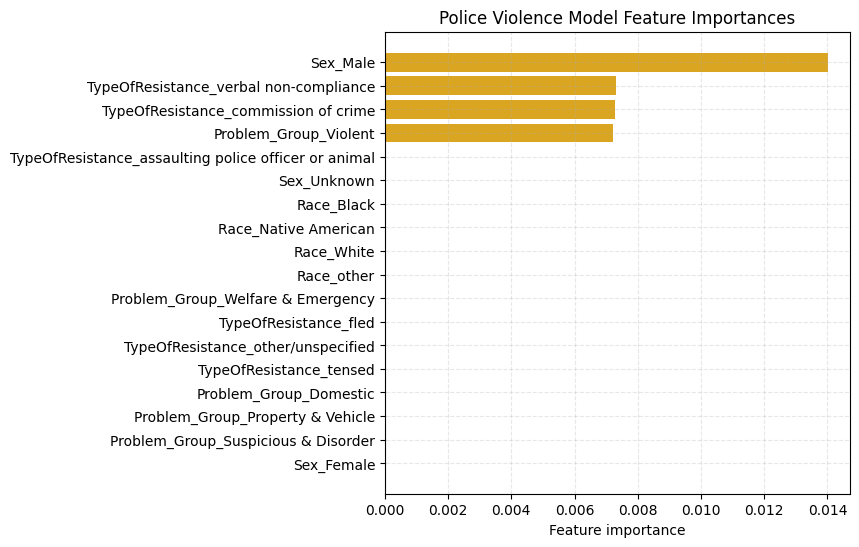

Max-depth 6 Tree
training accuracy: 0.7441542925413893


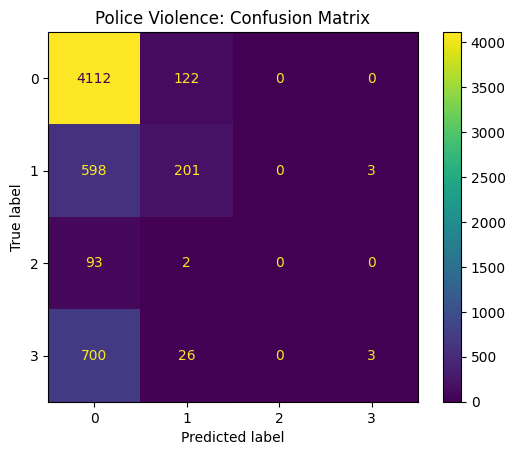

accuracy: 0.736518771331058
                     precision    recall  f1-score   support

       Bodily Force     0.7472    0.9712    0.8446      4234
  Chemical Irritant     0.5726    0.2506    0.3487       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.5000    0.0041    0.0082       729

           accuracy                         0.7365      5860
          macro avg     0.4550    0.3065    0.3004      5860
       weighted avg     0.6805    0.7365    0.6590      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

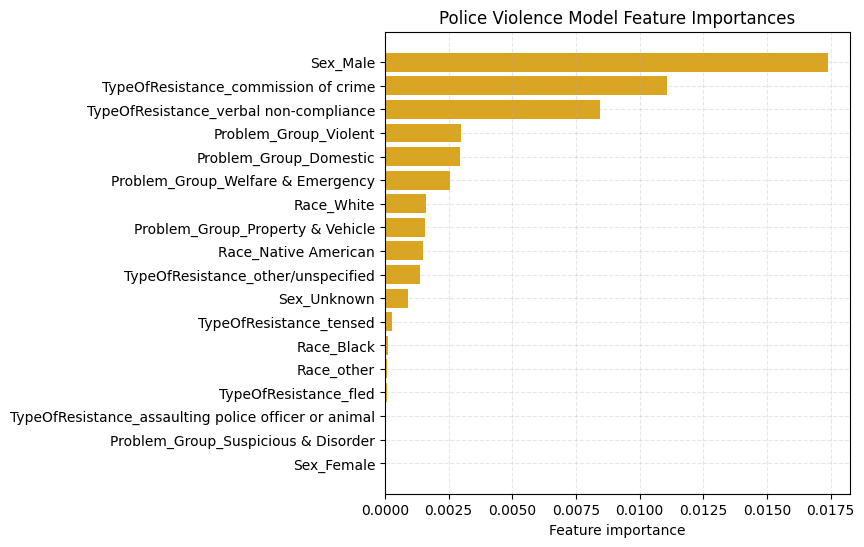

Max-depth 9 Tree
training accuracy: 0.745221027479092


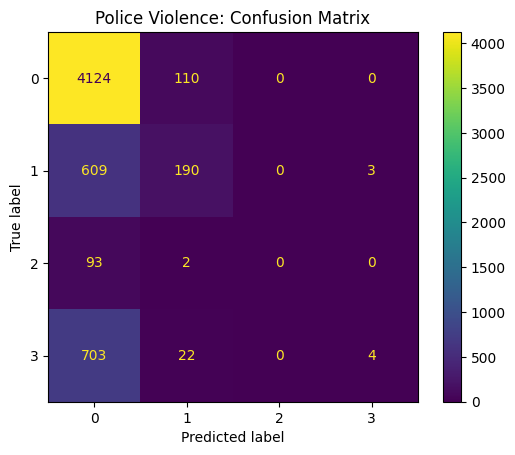

accuracy: 0.7368600682593857
                     precision    recall  f1-score   support

       Bodily Force     0.7459    0.9740    0.8448      4234
  Chemical Irritant     0.5864    0.2369    0.3375       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.5714    0.0055    0.0109       729

           accuracy                         0.7369      5860
          macro avg     0.4759    0.3041    0.2983      5860
       weighted avg     0.6903    0.7369    0.6579      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

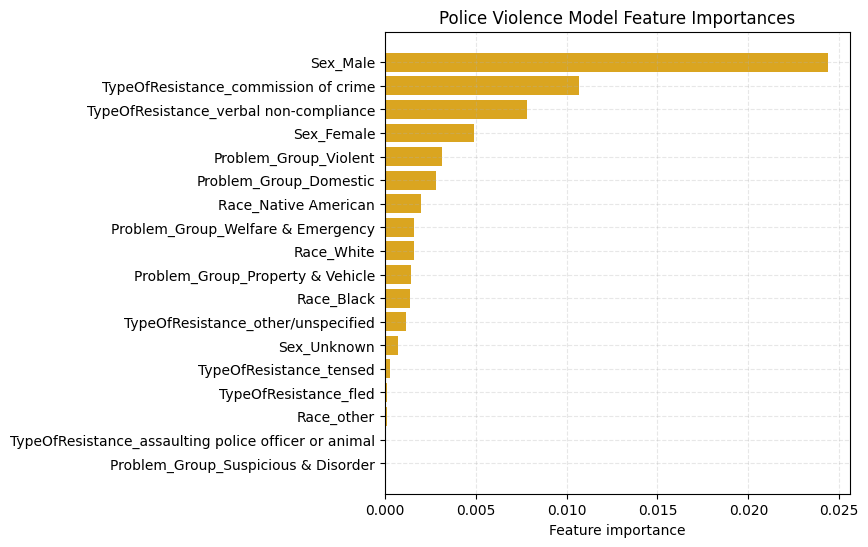

Max-depth 12 Tree
training accuracy: 0.7453917050691244


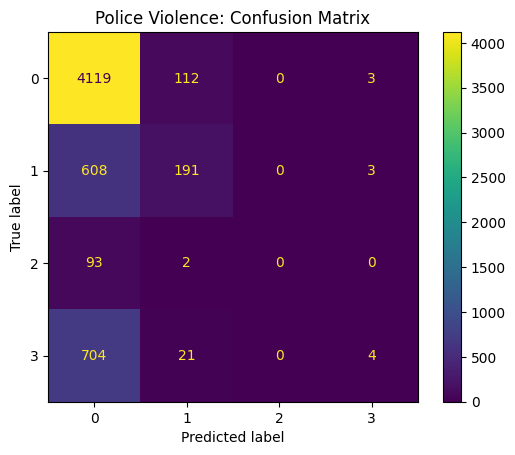

accuracy: 0.7361774744027304
                     precision    recall  f1-score   support

       Bodily Force     0.7457    0.9728    0.8442      4234
  Chemical Irritant     0.5859    0.2382    0.3387       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.4000    0.0055    0.0108       729

           accuracy                         0.7362      5860
          macro avg     0.4329    0.3041    0.2984      5860
       weighted avg     0.6687    0.7362    0.6577      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

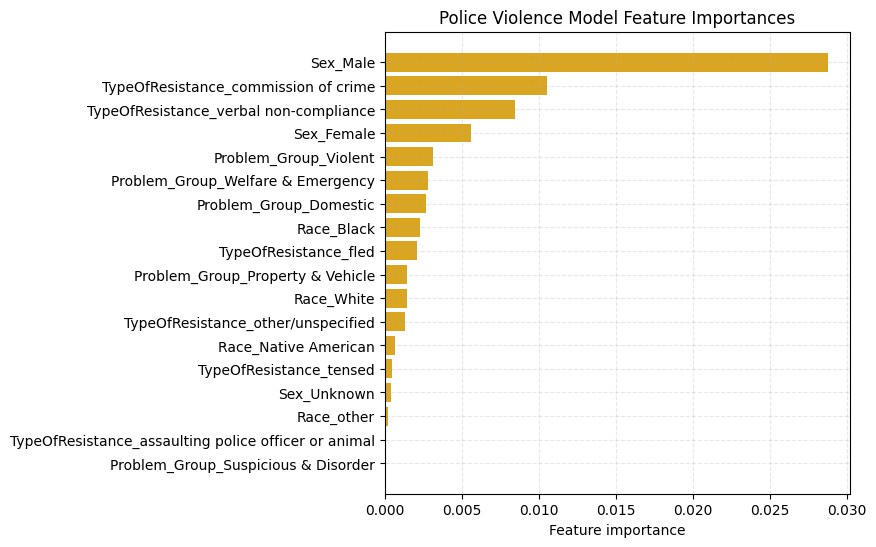

Max-depth 15 Tree
training accuracy: 0.7454343744666325


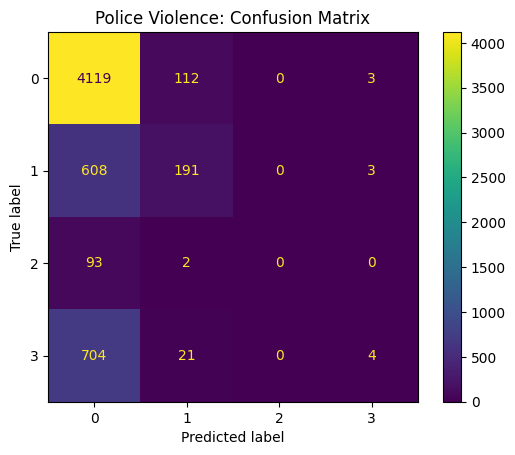

accuracy: 0.7361774744027304
                     precision    recall  f1-score   support

       Bodily Force     0.7457    0.9728    0.8442      4234
  Chemical Irritant     0.5859    0.2382    0.3387       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.4000    0.0055    0.0108       729

           accuracy                         0.7362      5860
          macro avg     0.4329    0.3041    0.2984      5860
       weighted avg     0.6687    0.7362    0.6577      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

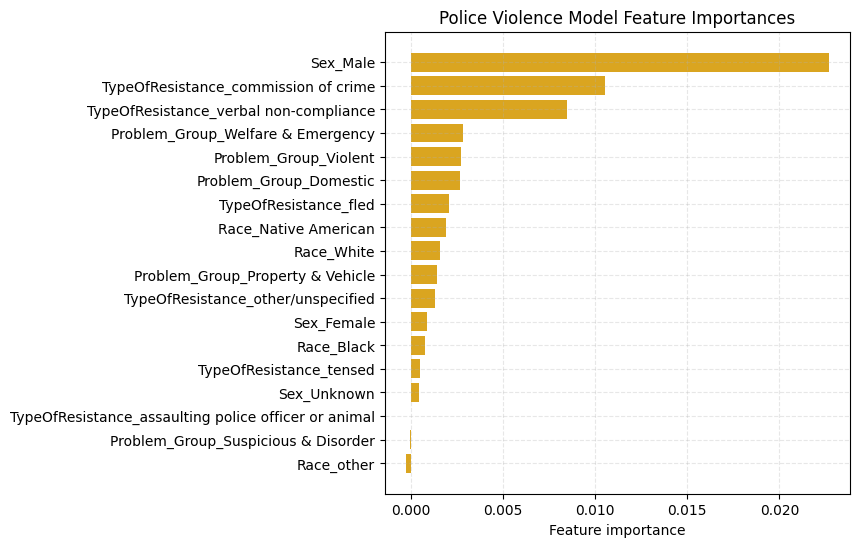

Max-depth 18 Tree
training accuracy: 0.7454343744666325


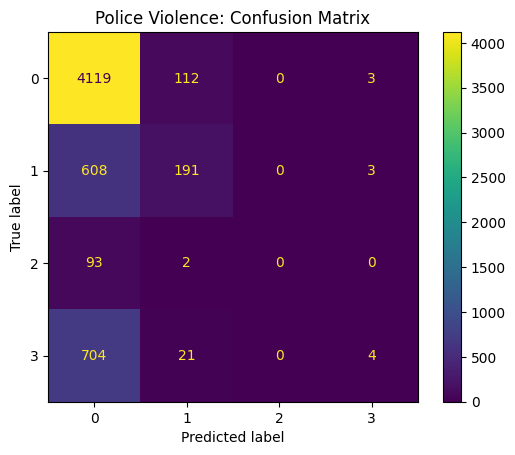

accuracy: 0.7361774744027304
                     precision    recall  f1-score   support

       Bodily Force     0.7457    0.9728    0.8442      4234
  Chemical Irritant     0.5859    0.2382    0.3387       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.4000    0.0055    0.0108       729

           accuracy                         0.7362      5860
          macro avg     0.4329    0.3041    0.2984      5860
       weighted avg     0.6687    0.7362    0.6577      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

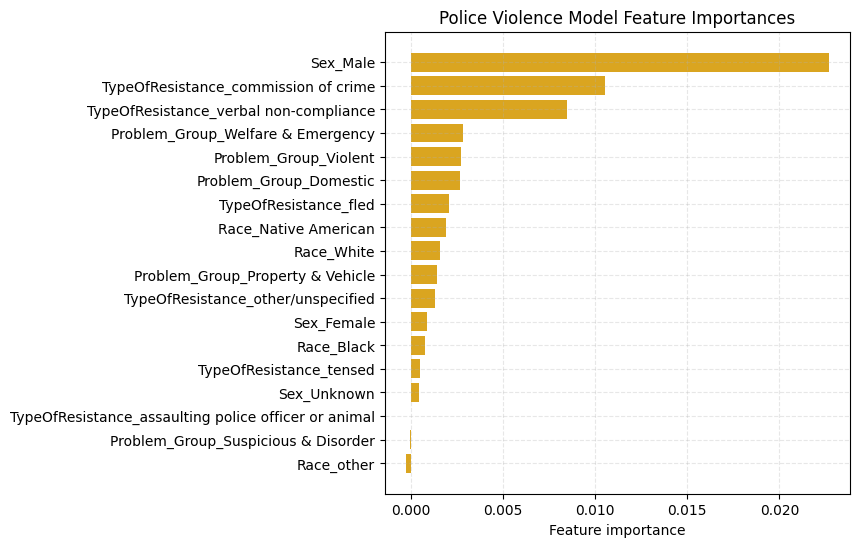

Max-depth 21 Tree
training accuracy: 0.7454343744666325


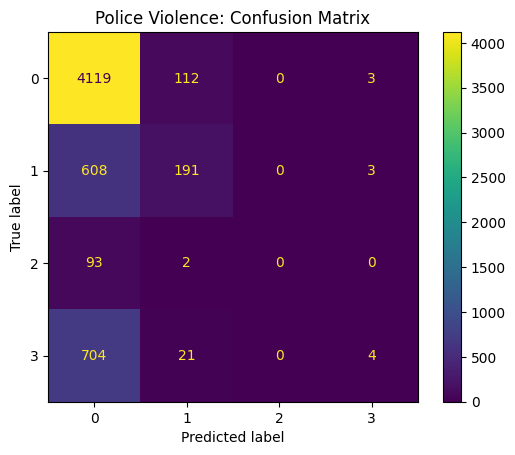

accuracy: 0.7361774744027304
                     precision    recall  f1-score   support

       Bodily Force     0.7457    0.9728    0.8442      4234
  Chemical Irritant     0.5859    0.2382    0.3387       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.4000    0.0055    0.0108       729

           accuracy                         0.7362      5860
          macro avg     0.4329    0.3041    0.2984      5860
       weighted avg     0.6687    0.7362    0.6577      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

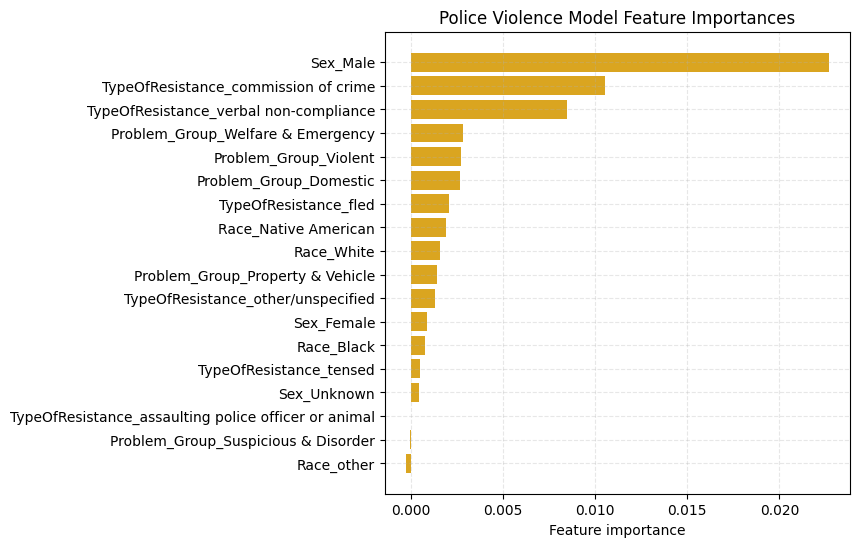

In [251]:
# fitting trees with 3, 6, 9, 12, 15, 18, 21 max layers
for i in range(3,22,3):
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=0)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    pred2 = clf.predict(X_train)
    print(f'Max-depth {i} Tree')
    accuracy = accuracy_score(y_train, pred2)
    print(f'training accuracy: {accuracy}')
    eval_tree(y_test, pred)
    
    # visualize the feature importances (which features led to the largest reduction in loss)
    names = X_train.columns.tolist()
    result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=0)
    importance_series = pd.Series(result.importances_mean, index=names).sort_values()
    # importances = pd.Series(clf.feature_importances_, index=names).sort_values()

    plt.figure(figsize=(6,6))
    plt.barh(importance_series.index, importance_series.values, color = 'goldenrod')
    plt.xlabel("Feature importance")
    plt.title("Police Violence Model Feature Importances")
    add_grid()
    plt.show()

The max_depth 9 tree seems like it works the best - it has the highest test accuracy, although it is missing target categories that are smaller. Even the deep trees, which should fit the data better, are missing smaller categories. 

### tree without 'problem' feature

In [243]:
X2 = df_final2.drop(columns = ['ForceType', 'Unnamed: 0'])
y2 = df_final2['ForceType']

In [244]:
# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded2 = pd.get_dummies(X2, columns= ['Sex', 'Race', 'TypeOfResistance'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_encoded2, y2, test_size=0.2, random_state=0)

X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape

((23436, 13), (5860, 13), (23436,), (5860,))

Max-depth 9 Tree
training accuracy: 0.7403567161631678


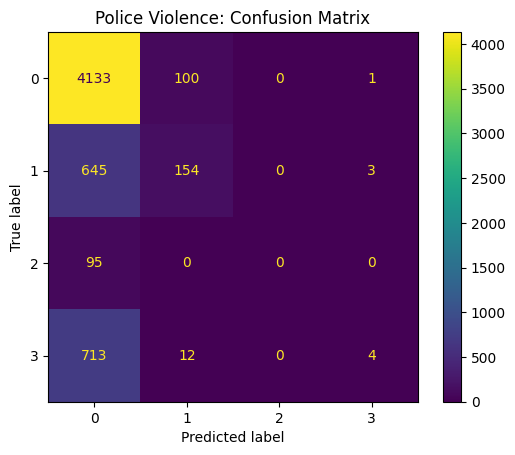

accuracy: 0.7322525597269625
                     precision    recall  f1-score   support

       Bodily Force     0.7399    0.9761    0.8418      4234
  Chemical Irritant     0.5789    0.1920    0.2884       802
               Guns     0.0000    0.0000    0.0000        95
Less Lethal Weapons     0.5000    0.0055    0.0109       729

           accuracy                         0.7323      5860
          macro avg     0.4547    0.2934    0.2852      5860
       weighted avg     0.6760    0.7323    0.6490      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

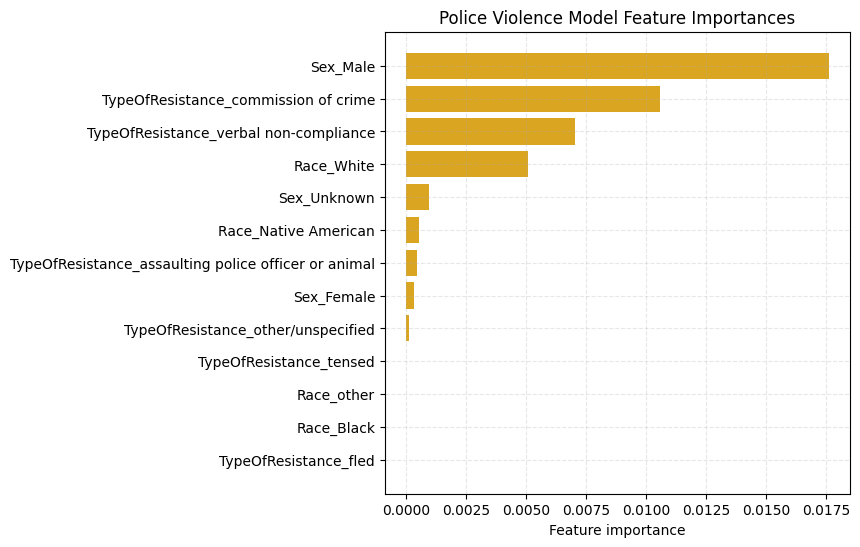

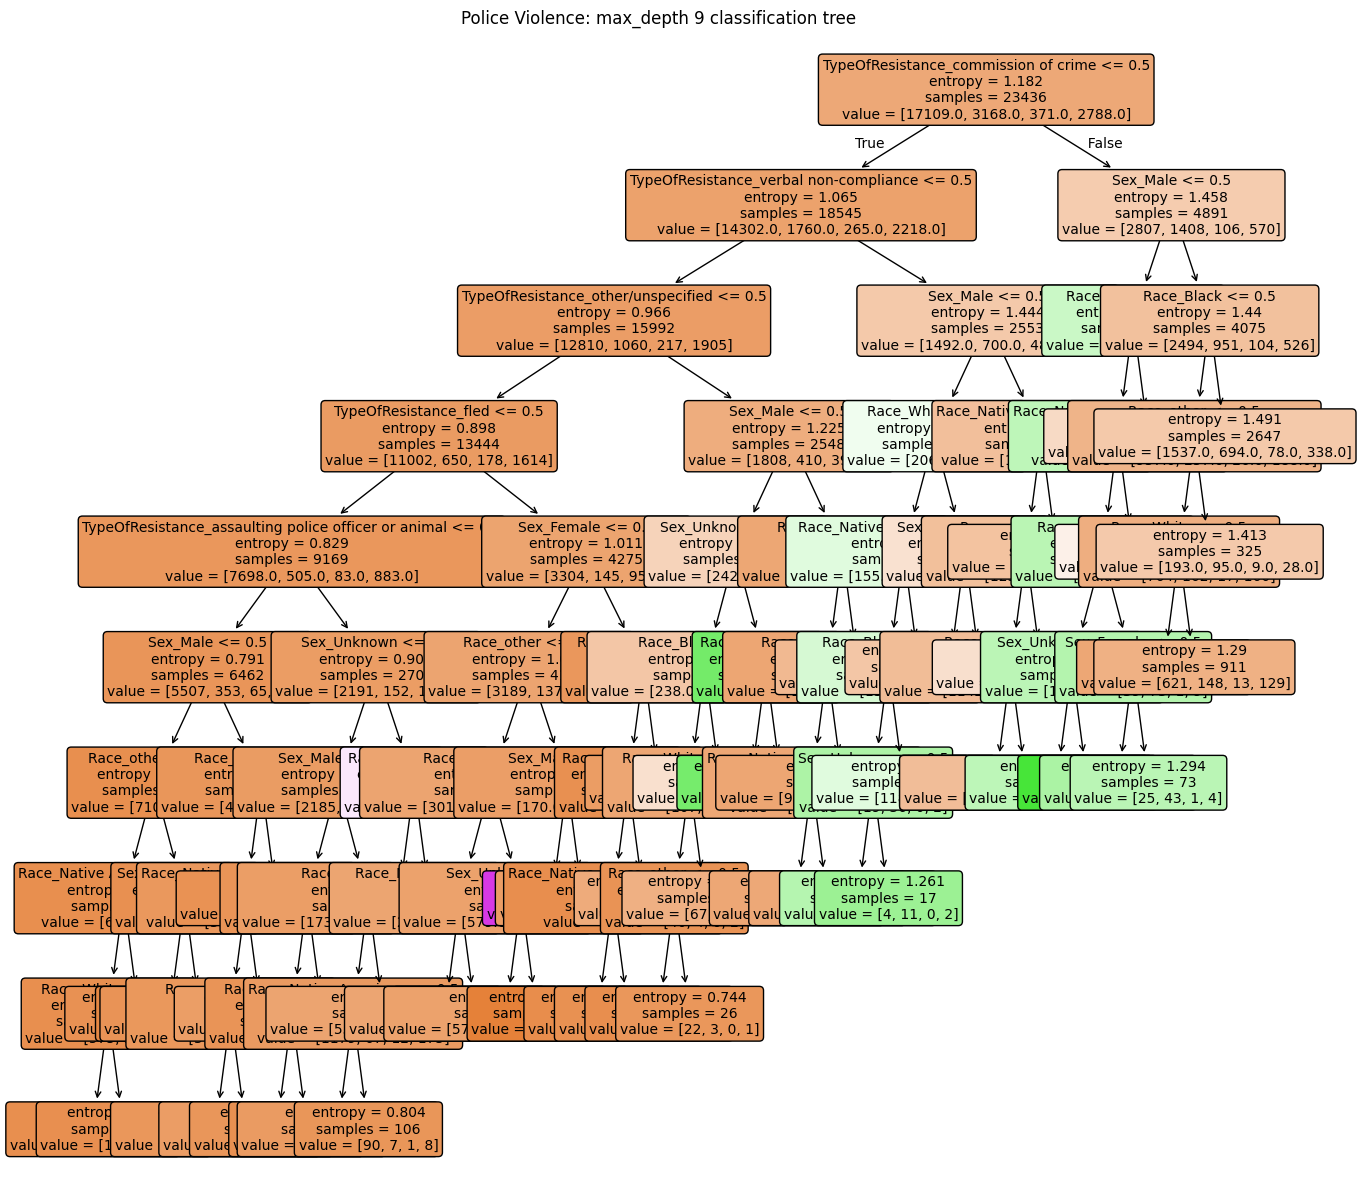

In [245]:
# fitting a max_depth 9 tree without the problem feature to see if that makes race/sex more clear as important
# since the problem has many categories and could skew importance because of that
i = 9
clf = DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state=0)
clf.fit(X_train2, y_train2)
pred = clf.predict(X_test2)
pred2 = clf.predict(X_train2)
print(f'Max-depth {i} Tree')
accuracy = accuracy_score(y_train2, pred2)
print(f'training accuracy: {accuracy}')
eval_tree(y_test2, pred)

# visualize the feature importances (which features led to the largest reduction in loss)
names = X_train2.columns.tolist()
result = permutation_importance(clf, X_test2, y_test2, n_repeats=10, random_state=0)
importance_series = pd.Series(result.importances_mean, index=names).sort_values()
# importances = pd.Series(clf.feature_importances_, index=names).sort_values()

plt.figure(figsize=(6,6))
plt.barh(importance_series.index, importance_series.values, color = 'goldenrod')
plt.xlabel("Feature importance")
plt.title("Police Violence Model Feature Importances")
add_grid()
plt.show()

# visualize the tree
plt.figure(figsize=(15, 15))
plot_tree(
    clf,
    feature_names= names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Police Violence: max_depth {i} classification tree")
plt.show()

Here is the tree visualized!! Also, taking out the Problem_group did help show that race and sex are the next most important, which is telling since the type of force used on someone is meant to be proportional to how much they are resisting officers (physically). 

Again, these single trees seem to be very susceptible to the class imbalance, and are mostly predicitng classes 0 and 1, which gives the model pretty high acuracy (regardless of the depth), but is missing a lot in terms of actually predicting all of the labels meaningfully. This is not necessarily overfitting, but boosting might be able to help by reducing bias when the smaller classes are weighed more heavily. 

## Boosting!

'balanced', it automatically assigns higher weights to minority class samples and lower weights to majority class samples based on the formula: nsamples (total samples) / [nclasses (number of classes) * nj (count of the given class)]

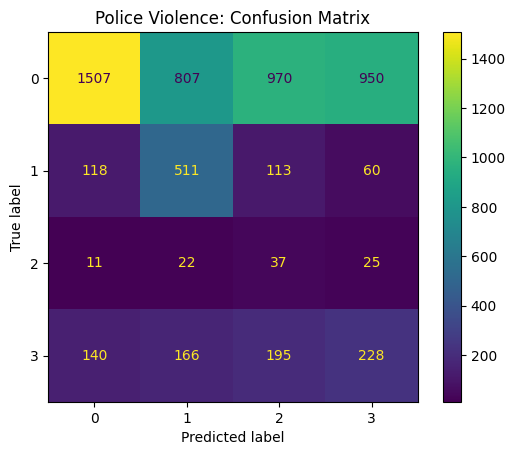

accuracy: 0.3895904436860068
                     precision    recall  f1-score   support

       Bodily Force     0.8485    0.3559    0.5015      4234
  Chemical Irritant     0.3393    0.6372    0.4428       802
               Guns     0.0281    0.3895    0.0525        95
Less Lethal Weapons     0.1805    0.3128    0.2289       729

           accuracy                         0.3896      5860
          macro avg     0.3491    0.4238    0.3064      5860
       weighted avg     0.6824    0.3896    0.4523      5860



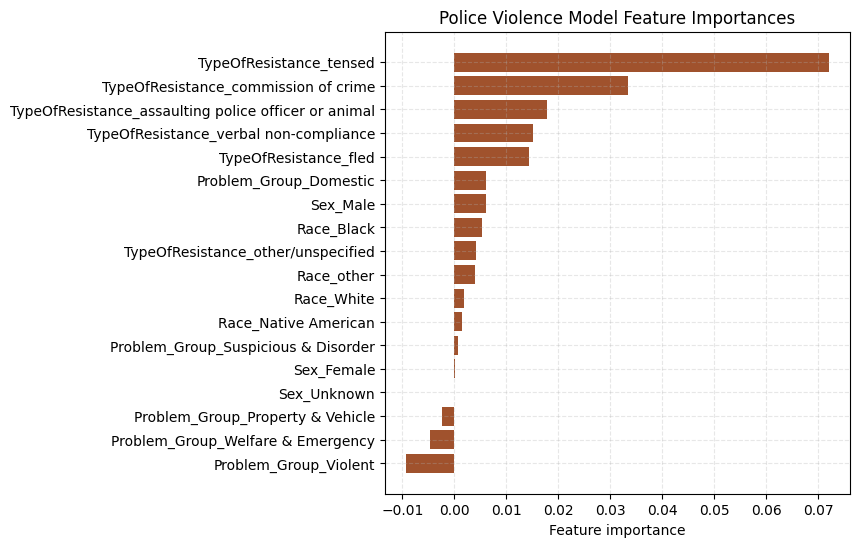

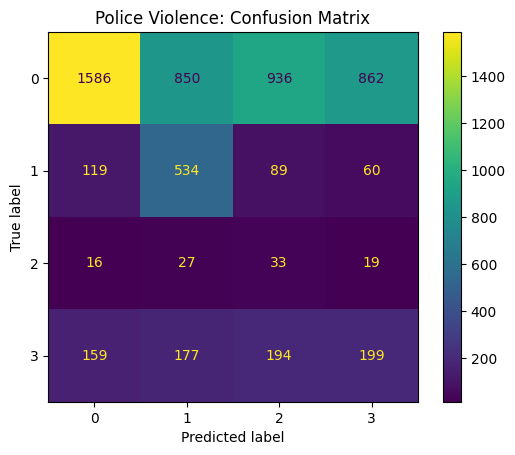

accuracy: 0.4013651877133106
                     precision    recall  f1-score   support

       Bodily Force     0.8436    0.3746    0.5188      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0264    0.3474    0.0490        95
Less Lethal Weapons     0.1746    0.2730    0.2129       729

           accuracy                         0.4014      5860
          macro avg     0.3452    0.4152    0.3069      5860
       weighted avg     0.6777    0.4014    0.4633      5860



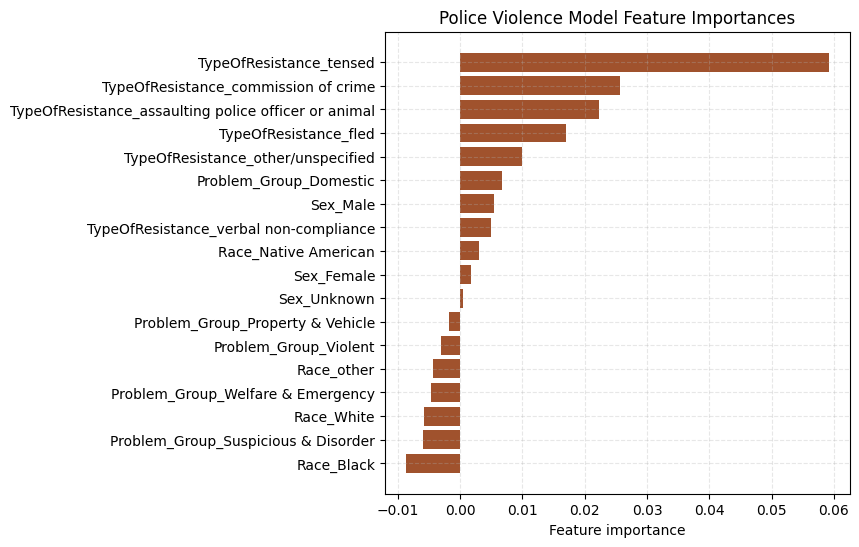

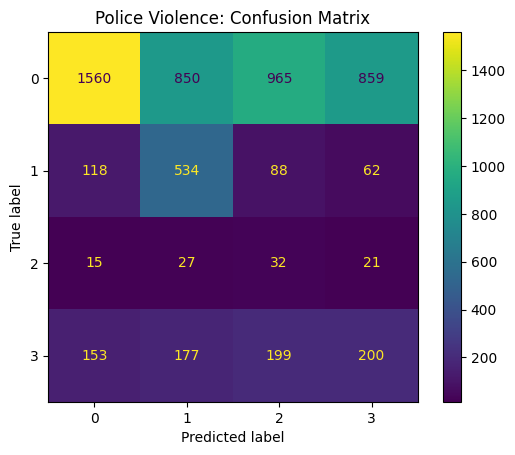

accuracy: 0.3969283276450512
                     precision    recall  f1-score   support

       Bodily Force     0.8451    0.3684    0.5132      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0249    0.3368    0.0464        95
Less Lethal Weapons     0.1751    0.2743    0.2138       729

           accuracy                         0.3969      5860
          macro avg     0.3453    0.4114    0.3051      5860
       weighted avg     0.6788    0.3969    0.4593      5860



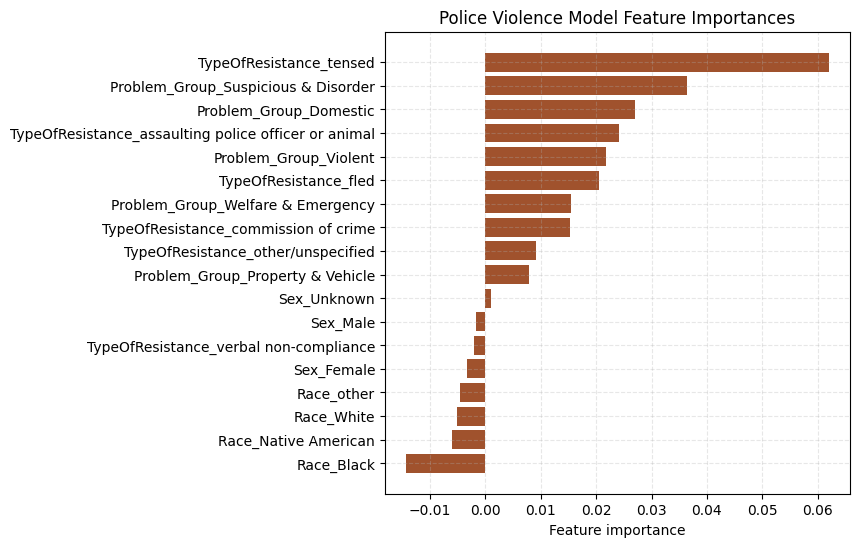

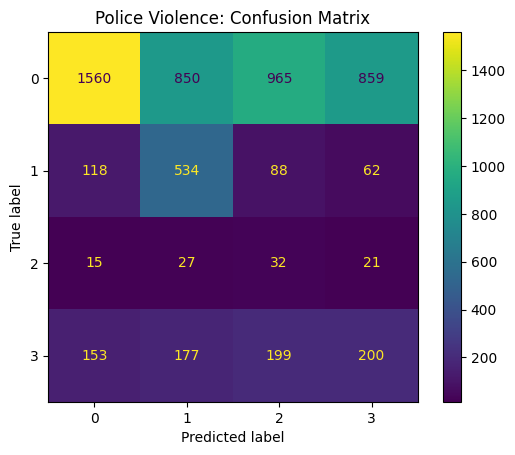

accuracy: 0.3969283276450512
                     precision    recall  f1-score   support

       Bodily Force     0.8451    0.3684    0.5132      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0249    0.3368    0.0464        95
Less Lethal Weapons     0.1751    0.2743    0.2138       729

           accuracy                         0.3969      5860
          macro avg     0.3453    0.4114    0.3051      5860
       weighted avg     0.6788    0.3969    0.4593      5860



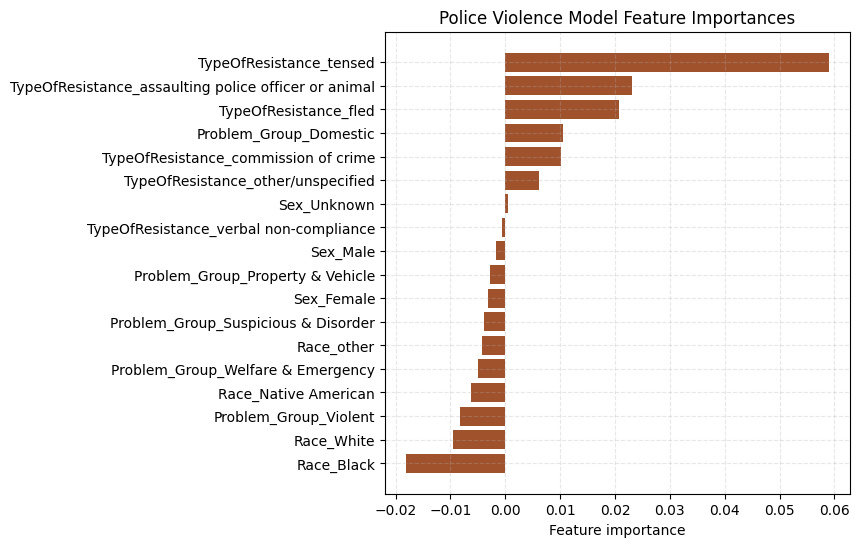

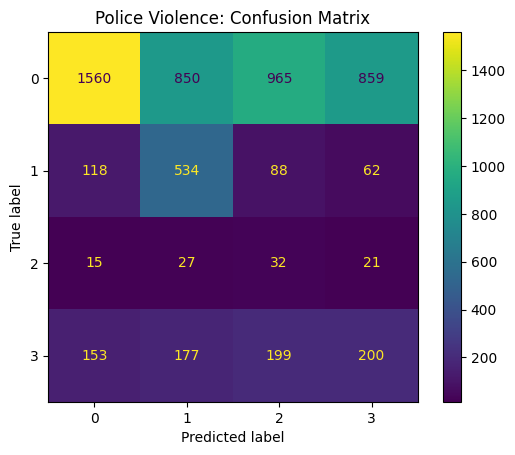

accuracy: 0.3969283276450512
                     precision    recall  f1-score   support

       Bodily Force     0.8451    0.3684    0.5132      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0249    0.3368    0.0464        95
Less Lethal Weapons     0.1751    0.2743    0.2138       729

           accuracy                         0.3969      5860
          macro avg     0.3453    0.4114    0.3051      5860
       weighted avg     0.6788    0.3969    0.4593      5860



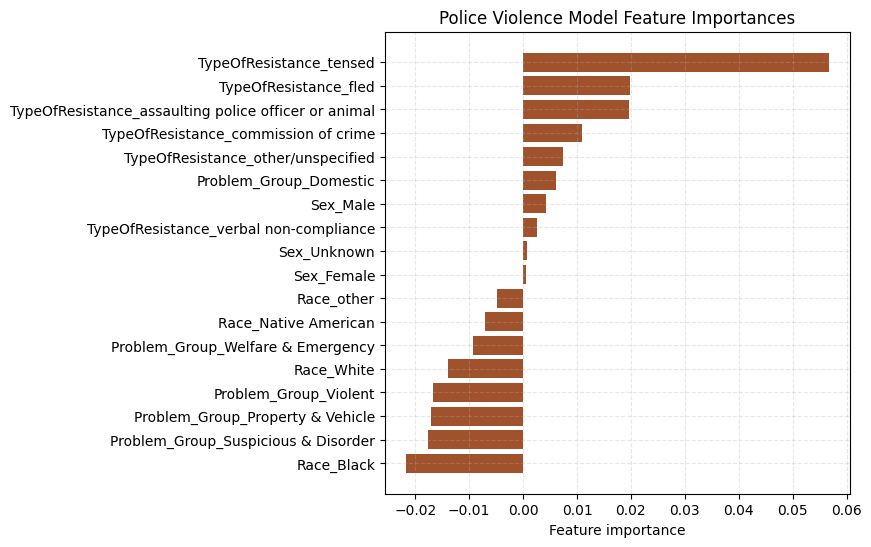

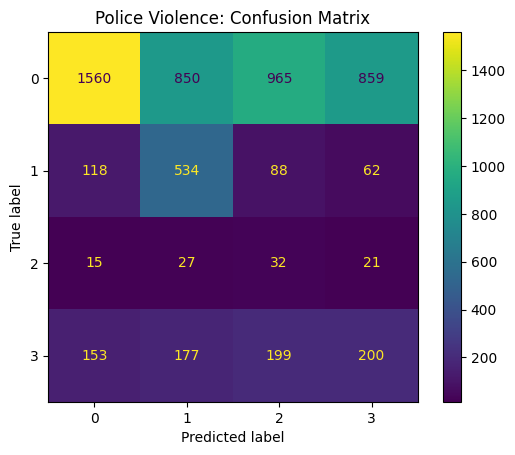

accuracy: 0.3969283276450512
                     precision    recall  f1-score   support

       Bodily Force     0.8451    0.3684    0.5132      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0249    0.3368    0.0464        95
Less Lethal Weapons     0.1751    0.2743    0.2138       729

           accuracy                         0.3969      5860
          macro avg     0.3453    0.4114    0.3051      5860
       weighted avg     0.6788    0.3969    0.4593      5860



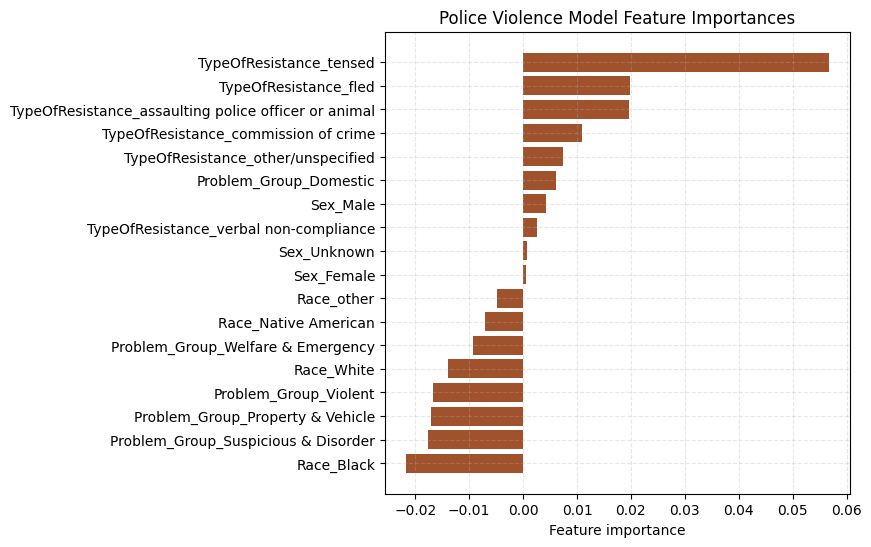

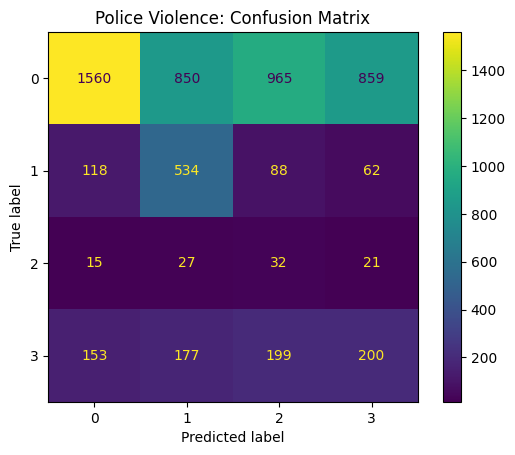

accuracy: 0.3969283276450512
                     precision    recall  f1-score   support

       Bodily Force     0.8451    0.3684    0.5132      4234
  Chemical Irritant     0.3363    0.6658    0.4469       802
               Guns     0.0249    0.3368    0.0464        95
Less Lethal Weapons     0.1751    0.2743    0.2138       729

           accuracy                         0.3969      5860
          macro avg     0.3453    0.4114    0.3051      5860
       weighted avg     0.6788    0.3969    0.4593      5860



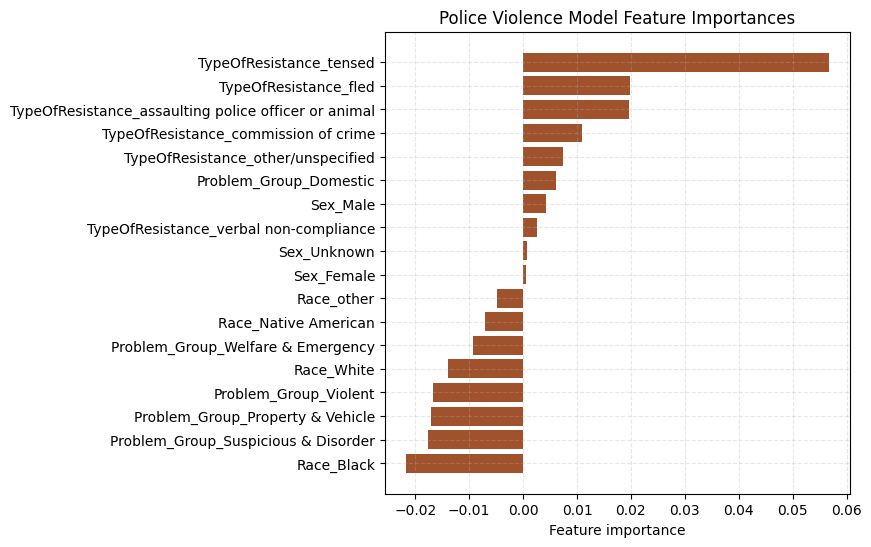

In [252]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

for i in range(3,22,3):
    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    boost_model = GradientBoostingClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=i, 
        random_state=0
    )

    # Fit and predict
    boost_model = boost_model.fit(X_train, y_train, sample_weight=weights)
    boost_preds = boost_model.predict(X_test)
    eval_tree(y_test, boost_preds)

    # visualize the feature importances (which features led to the largest reduction in loss)
    names = X_train.columns.tolist()
    result = permutation_importance(boost_model, X_test, y_test, n_repeats=10, random_state=0)
    importance_series = pd.Series(result.importances_mean, index=names).sort_values()
    # importances = pd.Series(clf.feature_importances_, index=names).sort_values()

    plt.figure(figsize=(6,6))
    plt.barh(importance_series.index, importance_series.values, color = 'sienna')
    plt.xlabel("Feature importance")
    plt.title("Police Violence Model Feature Importances")
    add_grid()
    plt.show()

The max_depth of 6 boosted tree has the highest test accuracy ~0.4, so this is the model we will use to analyze feature importance. It seems like race and sex are less important here, which is strange because they are pretty significant in the non-boosted trees. However, it seems like being Black is having a strong effect on the Type of Force for the deeper boosted models, which might be better at balancing bias and variance, and the only other category that is more important is 'tensed.'

In [265]:
# it kept creating new target categories, so for this once encoding the target to be numbers
# Bodily Force           21548
# Chemical Irritant       4125
# Less Lethal Weapons     3565
# Guns                     478
df_final['ForceType'] = df_final['ForceType'].replace('Bodily Force', 1)
df_final['ForceType'] = df_final['ForceType'].replace('Chemical Irritant', 2)
df_final['ForceType'] = df_final['ForceType'].replace('Less Lethal Weapons', 3)
df_final['ForceType'] = df_final['ForceType'].replace('Guns', 4)
print(df_final['ForceType'].value_counts())

X = df_final.drop(columns = ['ForceType', 'Unnamed: 0', 'CenterLatitude', 'CenterLongitude'])
y = df_final['ForceType']

# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

ForceType
1    21343
2     3970
3     3517
4      466
Name: count, dtype: int64


((23436, 18), (5860, 18), (23436,), (5860,))

In [266]:
X_train.head()

,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
7193,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
15903,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
14323,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
21947,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11094,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


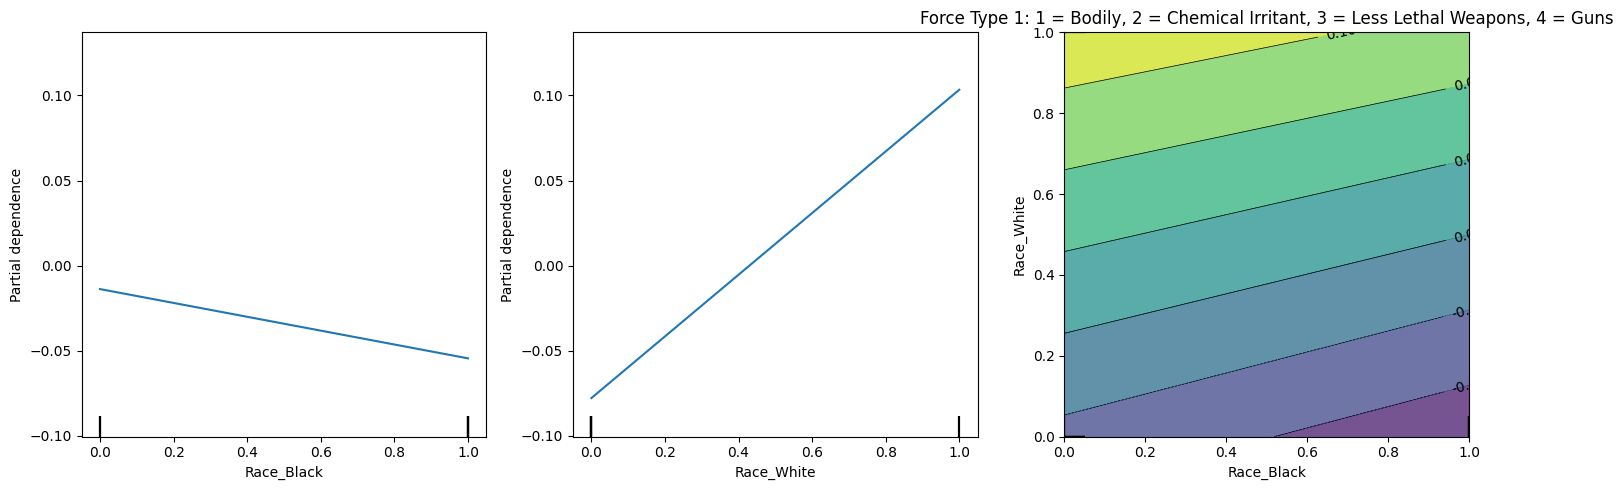

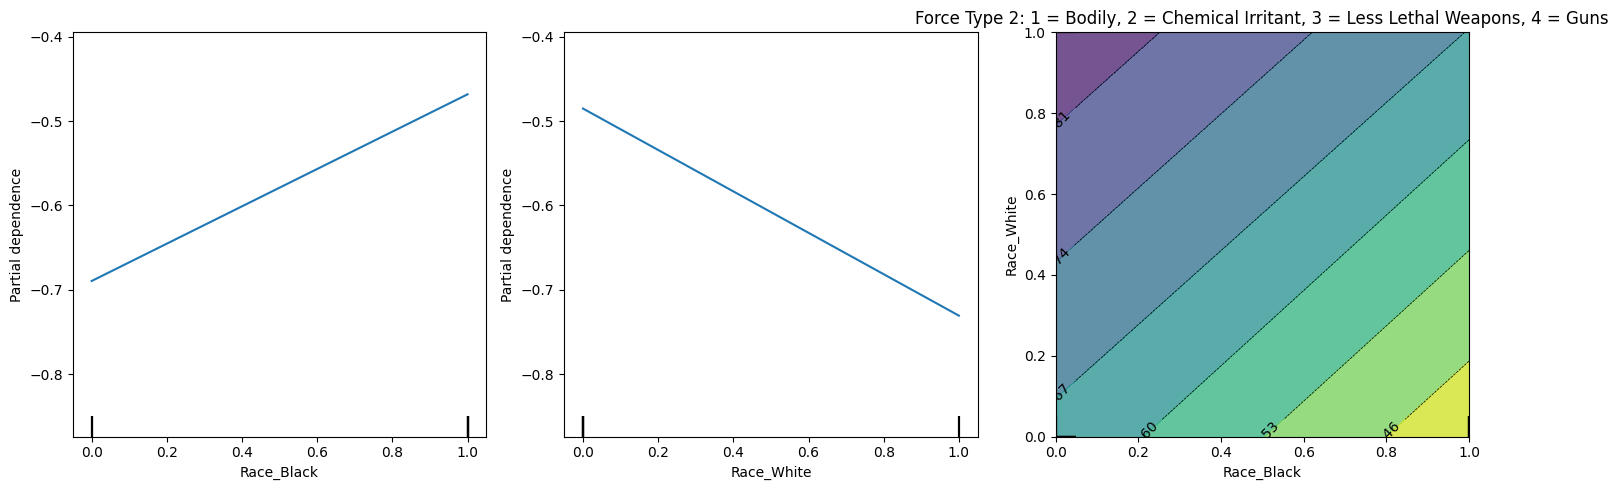

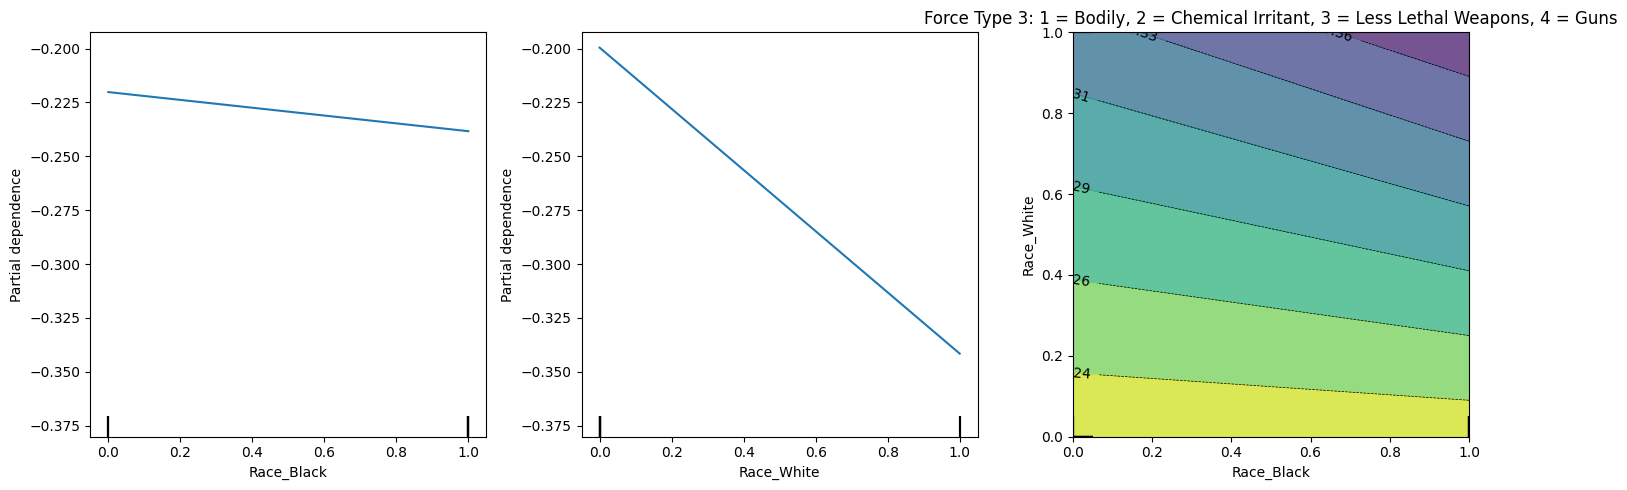

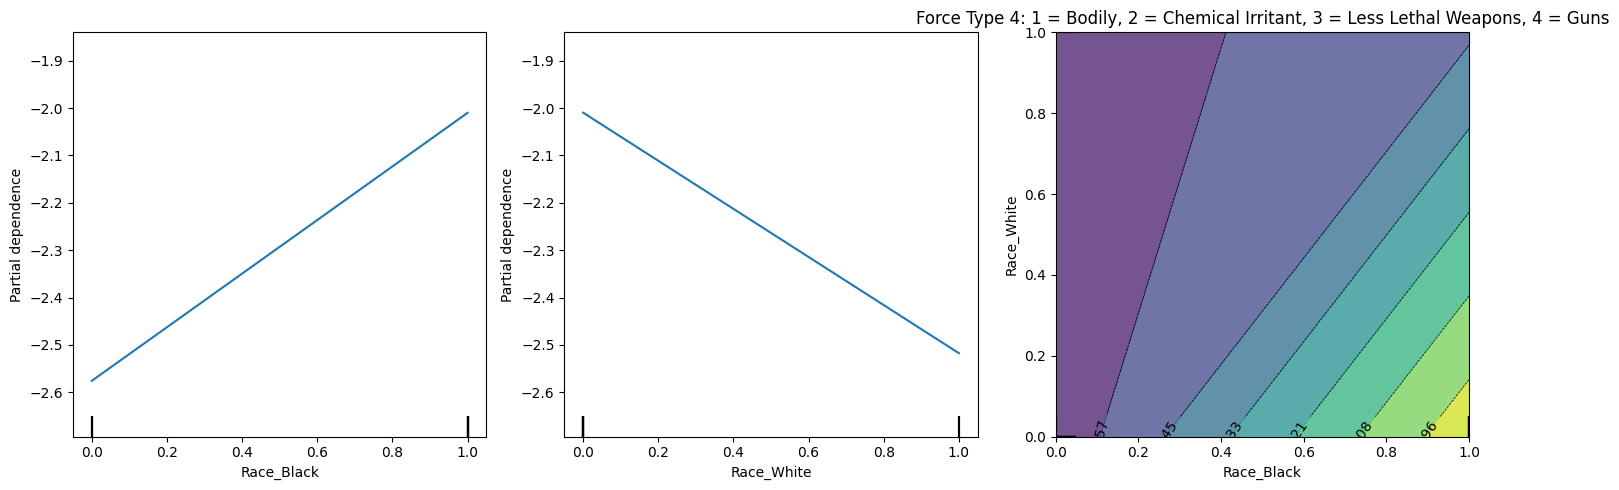

In [267]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)
boost_final = GradientBoostingClassifier(
        n_estimators=500, 
        learning_rate=0.1, 
        max_depth=6, # max depth 6 is the best from above 
        random_state=0
    )

    # Fit and predict
boost_final = boost_final.fit(X_train, y_train, sample_weight=weights)
boost_preds = boost_final.predict(X_test)

# looking at race first
for i in [1,2,3,4]:
# using the best boosted model and then iterating through all of the force types
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
    
    display = PartialDependenceDisplay.from_estimator(
        boost_final, 
        X_encoded, 
        features=[3, 5, (3, 5)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.tight_layout()
    plt.show()

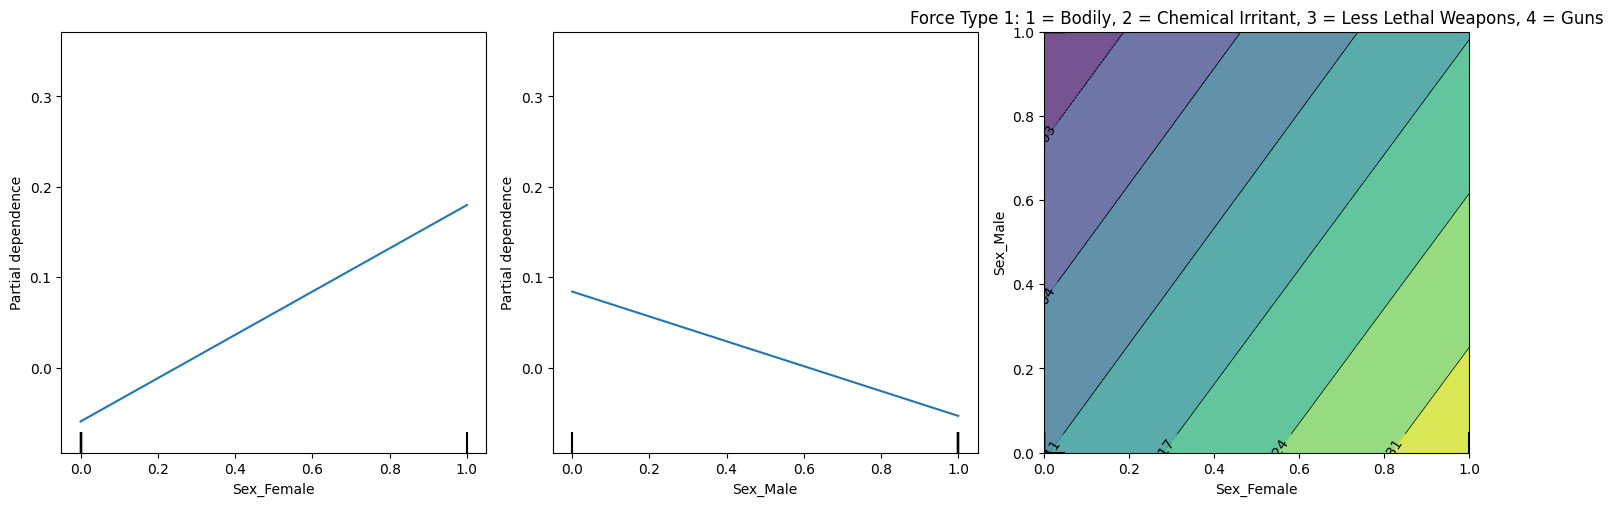

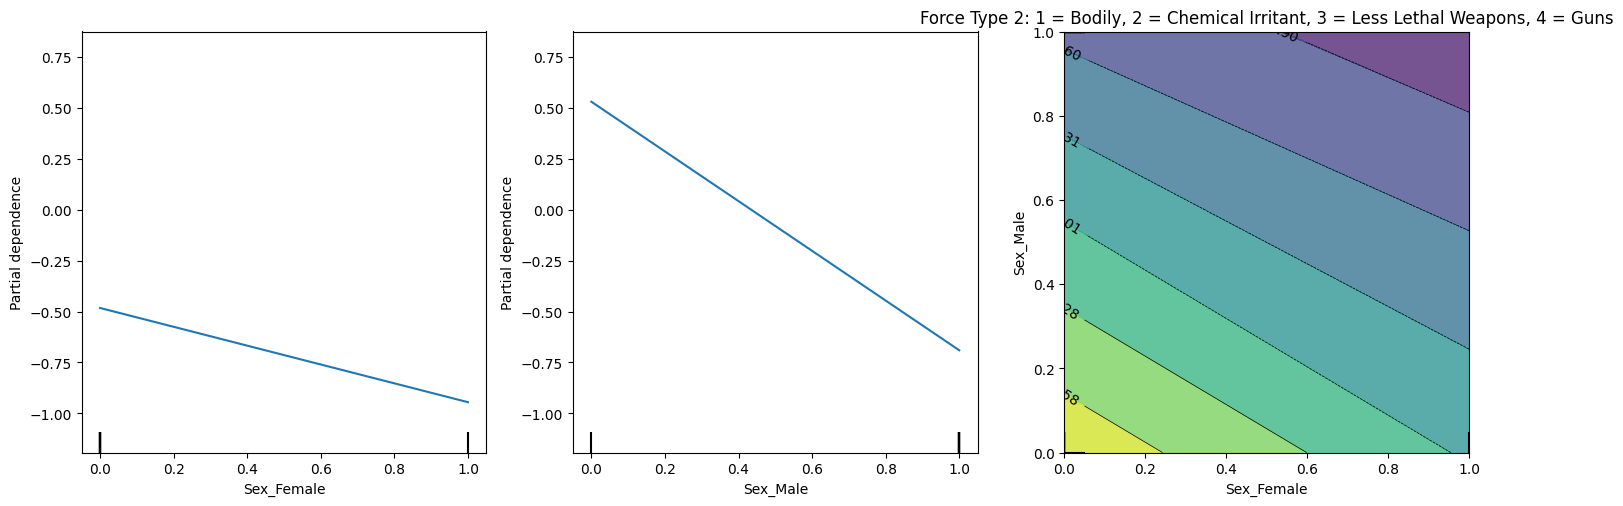

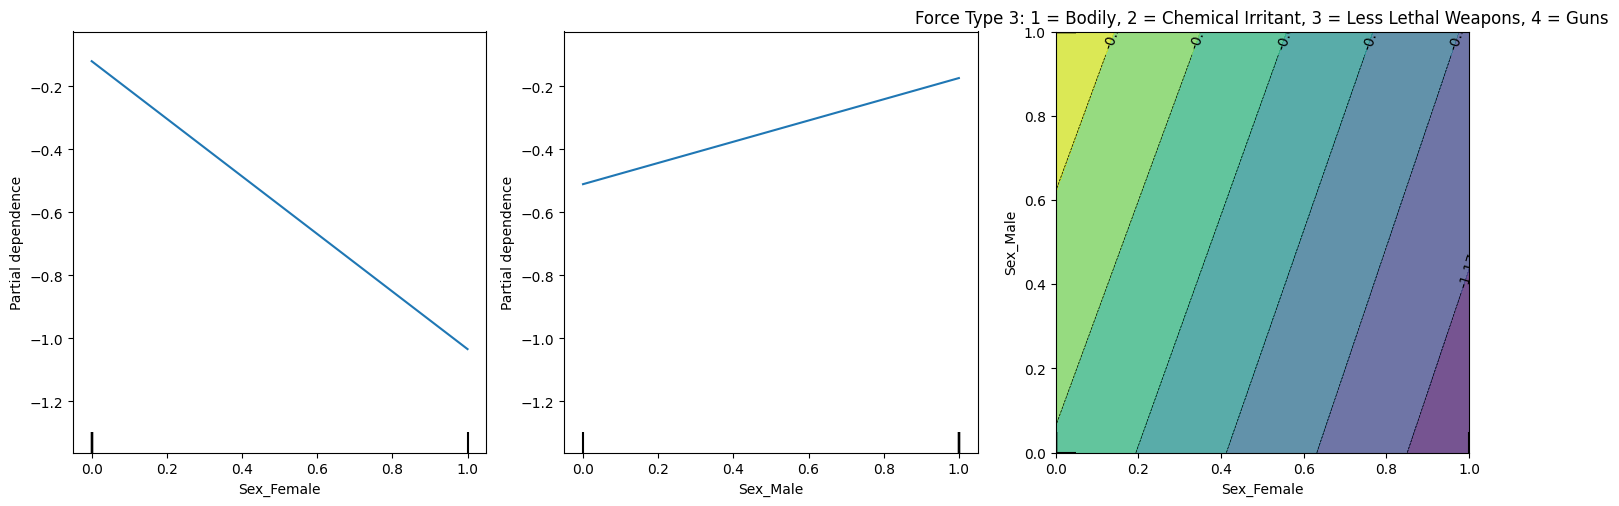

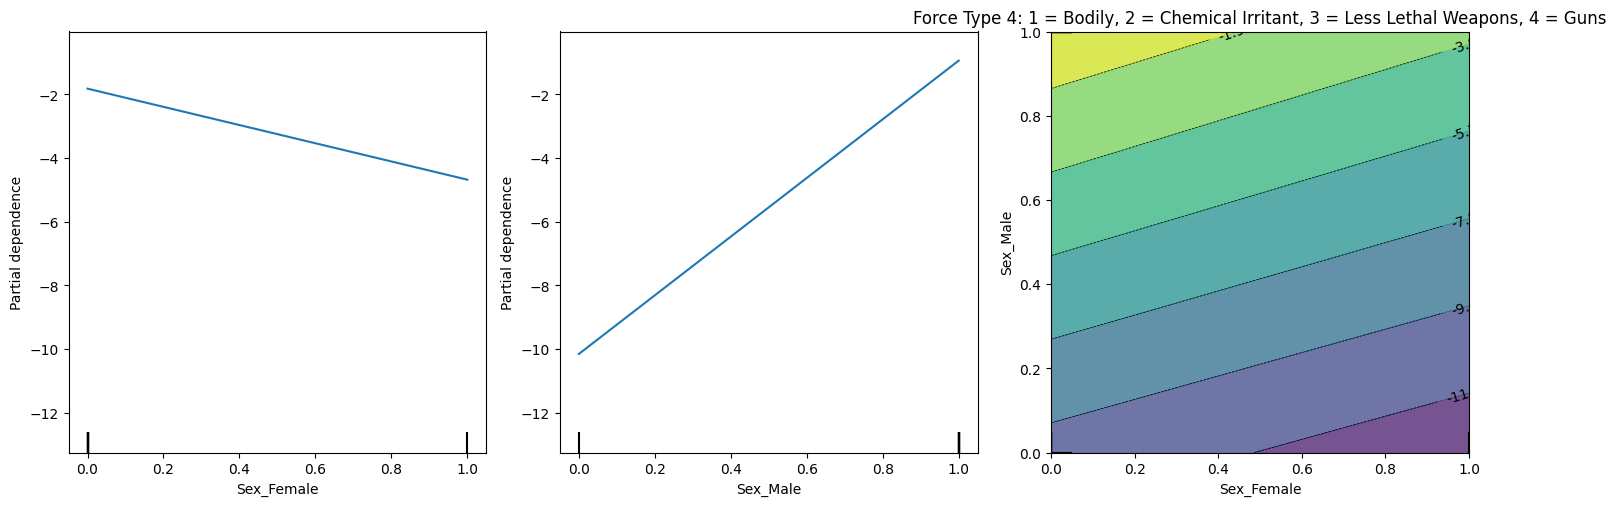

In [268]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)
boost_final = GradientBoostingClassifier(
        n_estimators=500, 
        learning_rate=0.1, 
        max_depth=6, # max depth 6 is the best from above 
        random_state=0
    )

    # Fit and predict
boost_final = boost_final.fit(X_train, y_train, sample_weight=weights)
boost_preds = boost_final.predict(X_test)

# now looking at sex
for i in [1,2,3,4]:
# calling the best random forrest model
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
    
    display = PartialDependenceDisplay.from_estimator(
        boost_final, 
        X_encoded, 
        features=[0, 1, (0, 1)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.tight_layout()
    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.show()

Now I want to do this again, but by Dr. Gerber's suggestion add in longitude and latitude values to see how import they are.

In [276]:
# it kept creating new target categories, so for this once encoding the target to be numbers
# Bodily Force           21548
# Chemical Irritant       4125
# Less Lethal Weapons     3565
# Guns                     478
df_final['ForceType'] = df_final['ForceType'].replace('Bodily Force', 1)
df_final['ForceType'] = df_final['ForceType'].replace('Chemical Irritant', 2)
df_final['ForceType'] = df_final['ForceType'].replace('Less Lethal Weapons', 3)
df_final['ForceType'] = df_final['ForceType'].replace('Guns', 4)
print(df_final['ForceType'].value_counts())

X = df_final.drop(columns = ['ForceType', 'Unnamed: 0'])
y = df_final['ForceType']

# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)
X_train.head()

ForceType
1    21343
2     3970
3     3517
4      466
Name: count, dtype: int64


,CenterLongitude,CenterLatitude,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
7193,-93.298199,44.991192,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
15903,-93.271963,44.981655,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
14323,-93.297177,44.993608,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
21947,-93.250304,44.970168,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11094,-93.258830,44.946091,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


In [279]:
from sklearn.preprocessing import StandardScaler

#adding in scaled longitude and latitude
X_tr_numeric = X_train[['CenterLongitude', 'CenterLatitude']]
X_te_numeric = X_test[['CenterLongitude', 'CenterLatitude']]
X_tr_other = X_train[['Sex_Female', 'Sex_Male', 'Sex_Unknown', 'Race_Black', 'Race_Native American', 'Race_White', 'Race_other', 'TypeOfResistance_assaulting police officer or animal', 'TypeOfResistance_commission of crime', 'TypeOfResistance_fled', 'TypeOfResistance_other/unspecified', 'TypeOfResistance_tensed', 'TypeOfResistance_verbal non-compliance', 'Problem_Group_Domestic', 'Problem_Group_Property & Vehicle', 'Problem_Group_Suspicious & Disorder', 'Problem_Group_Violent', 'Problem_Group_Welfare & Emergency']]
X_te_other = X_test[['Sex_Female', 'Sex_Male', 'Sex_Unknown', 'Race_Black', 'Race_Native American', 'Race_White', 'Race_other', 'TypeOfResistance_assaulting police officer or animal', 'TypeOfResistance_commission of crime', 'TypeOfResistance_fled', 'TypeOfResistance_other/unspecified', 'TypeOfResistance_tensed', 'TypeOfResistance_verbal non-compliance', 'Problem_Group_Domestic', 'Problem_Group_Property & Vehicle', 'Problem_Group_Suspicious & Disorder', 'Problem_Group_Violent', 'Problem_Group_Welfare & Emergency']]

scaler = StandardScaler()
scaler.fit(X_tr_numeric)

X_tr_s = scaler.transform(X_tr_numeric)
X_te_s = scaler.transform(X_te_numeric)

X_tr_final = np.hstack((X_tr_s, X_tr_other))
X_te_final = np.hstack((X_te_s, X_te_other))

X_tr_final[0], X_te_final[0], y_train.shape, y_test.shape

(array([-1.06911746,  0.45775319,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ]),
 array([ 1.22986246, -0.84215274,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ]),
 (23436,),
 (5860,))

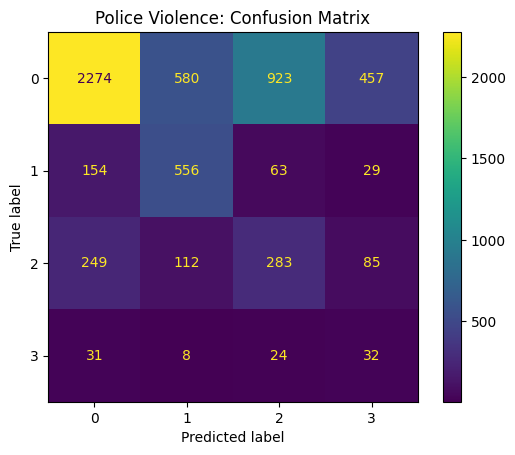

accuracy: 0.5366894197952219
              precision    recall  f1-score   support

           1     0.8397    0.5371    0.6551      4234
           2     0.4427    0.6933    0.5403       802
           3     0.2189    0.3882    0.2799       729
           4     0.0531    0.3368    0.0917        95

    accuracy                         0.5367      5860
   macro avg     0.3886    0.4888    0.3918      5860
weighted avg     0.6954    0.5367    0.5836      5860



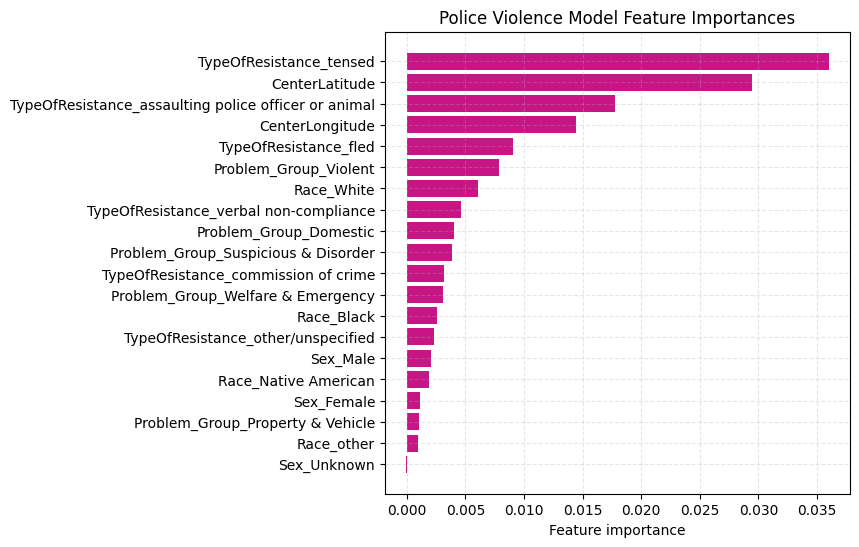

In [280]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)
boost_model = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=0
)

# Fit and predict
boost_model = boost_model.fit(X_tr_final, y_train, sample_weight=weights)
boost_preds = boost_model.predict(X_te_final)
eval_tree(y_test, boost_preds)

# visualize the feature importances (which features led to the largest reduction in loss)
names = X_train.columns.tolist()
result = permutation_importance(boost_model, X_te_final, y_test, n_repeats=10, random_state=0)
importance_series = pd.Series(result.importances_mean, index=names).sort_values()
# importances = pd.Series(clf.feature_importances_, index=names).sort_values()

plt.figure(figsize=(6,6))
plt.barh(importance_series.index, importance_series.values, color = 'mediumvioletred')
plt.xlabel("Feature importance")
plt.title("Police Violence Model Feature Importances")
add_grid()
plt.show()

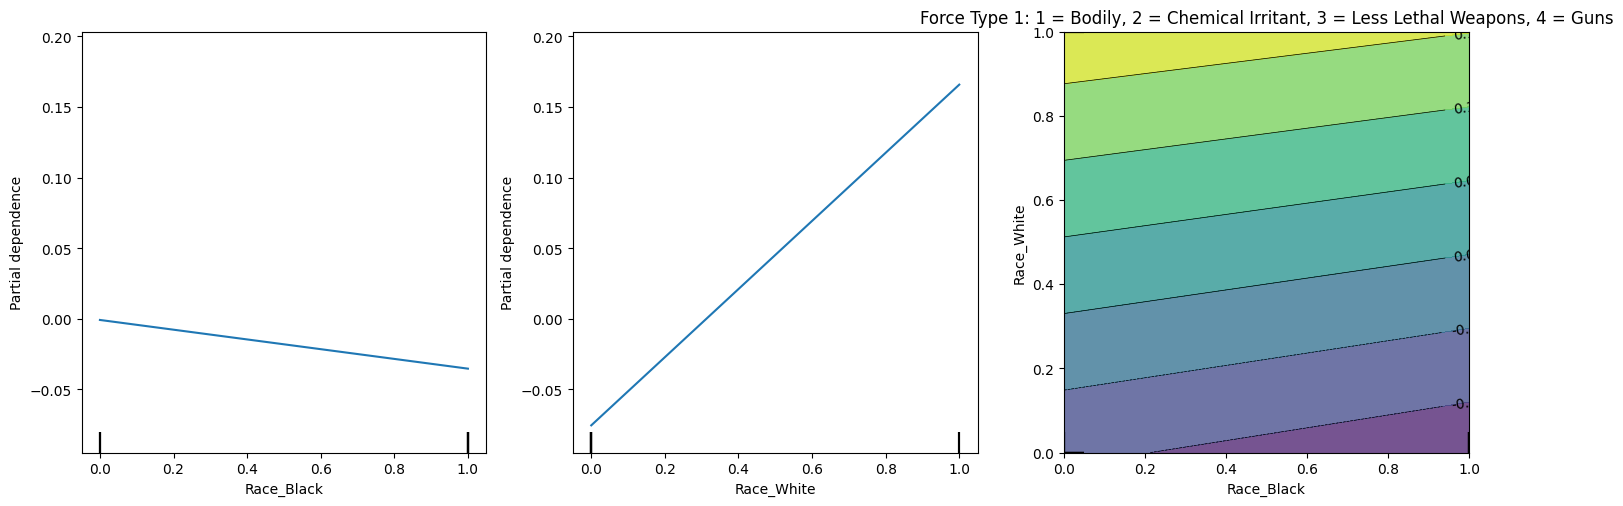

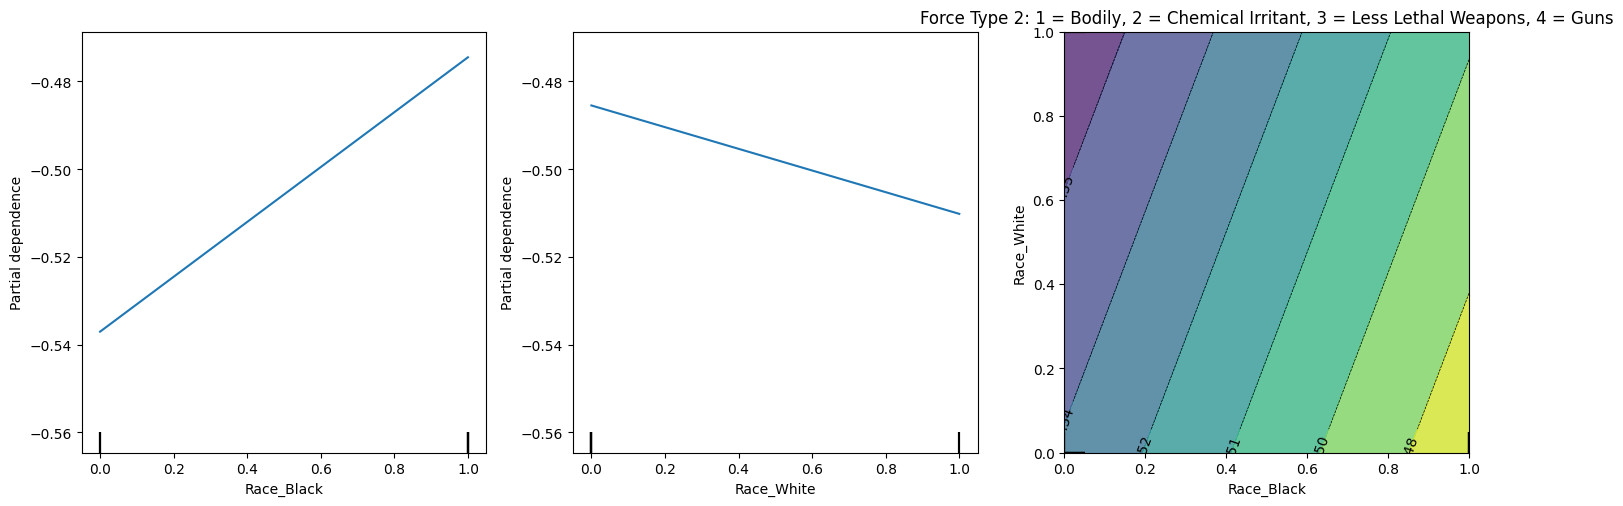

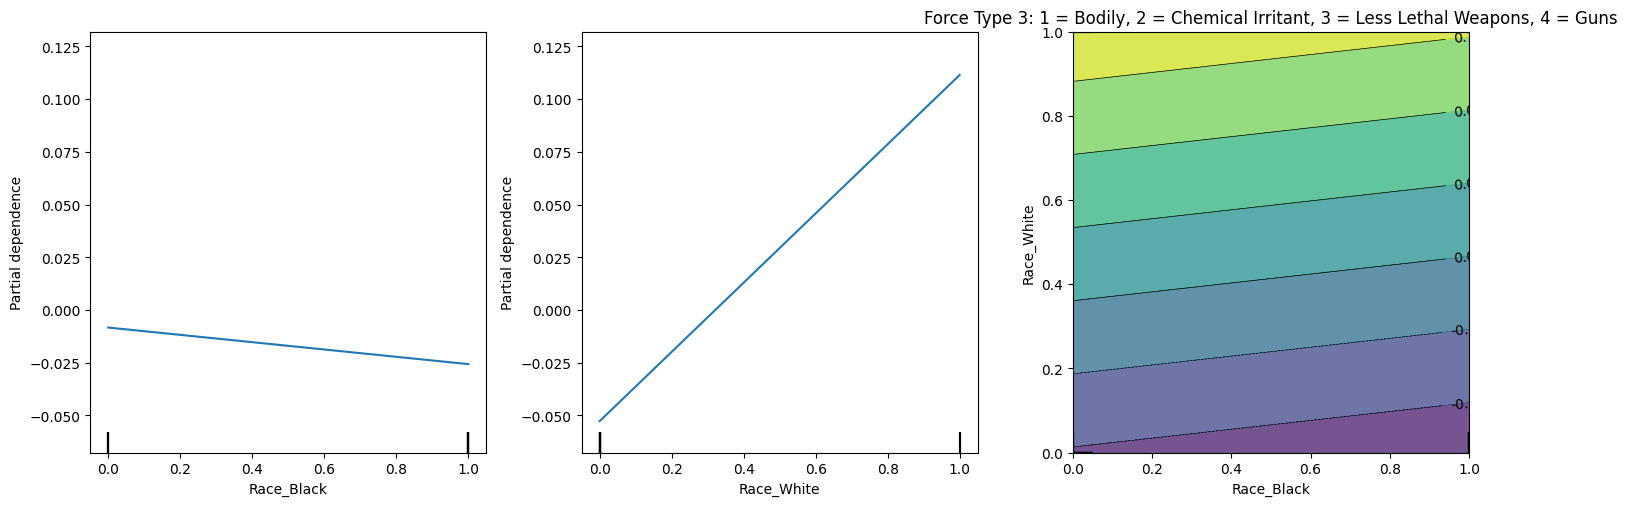

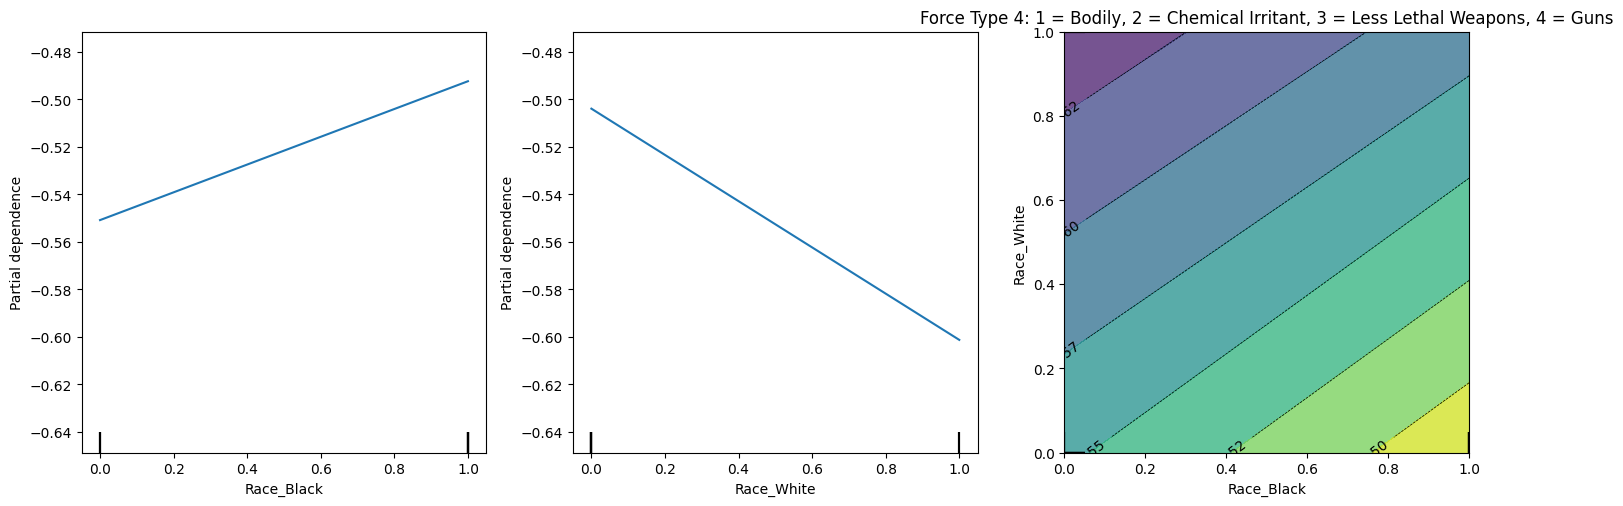

In [281]:
# seeing how adding the location changes the PD race plots
for i in [1,2,3,4]:
# calling the best random forrest model
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
    
    display = PartialDependenceDisplay.from_estimator(
        boost_model, 
        X_encoded, 
        features=[5, 7, (5, 7)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.tight_layout()
    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.show()

## Random Forest

Now trying random forest to balance variance, even though this honestly doesn't seem like our main problem. 

In [282]:
# it kept creating new target categories, so for this once encoding the target to be numbers
# Bodily Force           21548
# Chemical Irritant       4125
# Less Lethal Weapons     3565
# Guns                     478
df_final['ForceType'] = df_final['ForceType'].replace('Bodily Force', 1)
df_final['ForceType'] = df_final['ForceType'].replace('Chemical Irritant', 2)
df_final['ForceType'] = df_final['ForceType'].replace('Less Lethal Weapons', 3)
df_final['ForceType'] = df_final['ForceType'].replace('Guns', 4)
print(df_final['ForceType'].value_counts())

X = df_final.drop(columns = ['ForceType', 'Unnamed: 0', 'CenterLongitude', 'CenterLatitude'])
y = df_final['ForceType']

# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)
X_train.head()

ForceType
1    21343
2     3970
3     3517
4      466
Name: count, dtype: int64


,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
7193,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
15903,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
14323,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
21947,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11094,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


18


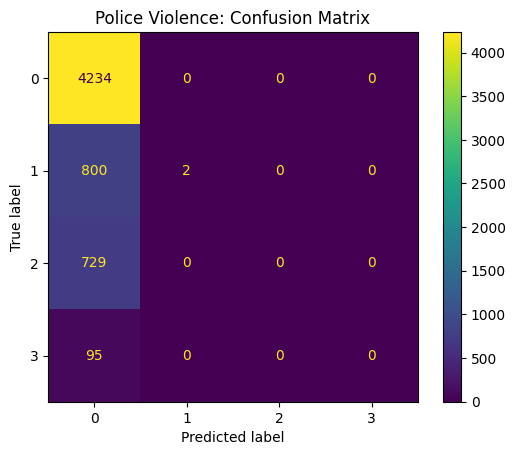

accuracy: 0.7228668941979522
              precision    recall  f1-score   support

           1     0.7228    1.0000    0.8391      4234
           2     1.0000    0.0025    0.0050       802
           3     0.0000    0.0000    0.0000       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7229      5860
   macro avg     0.4307    0.2506    0.2110      5860
weighted avg     0.6591    0.7229    0.6069      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

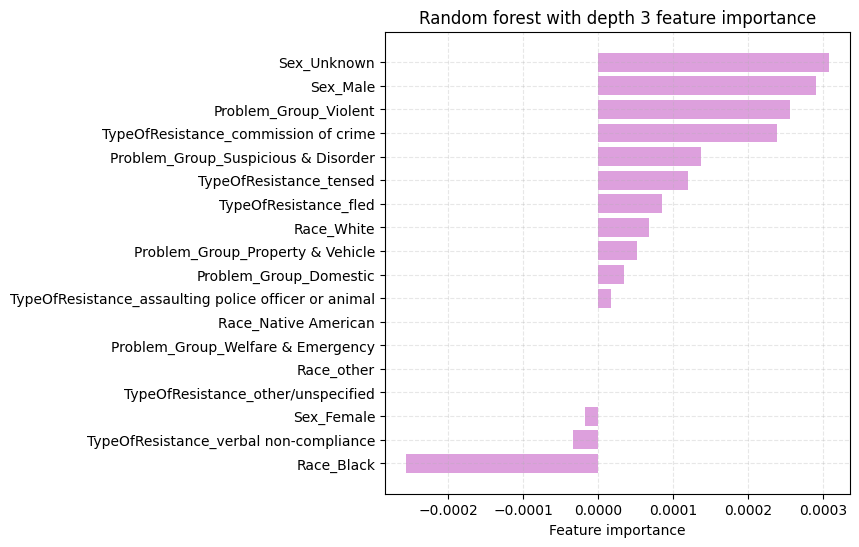

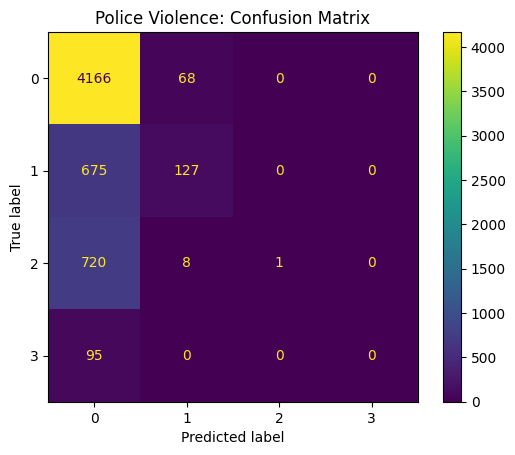

accuracy: 0.7327645051194539
              precision    recall  f1-score   support

           1     0.7366    0.9839    0.8425      4234
           2     0.6256    0.1584    0.2527       802
           3     1.0000    0.0014    0.0027       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7328      5860
   macro avg     0.5905    0.2859    0.2745      5860
weighted avg     0.7422    0.7328    0.6436      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

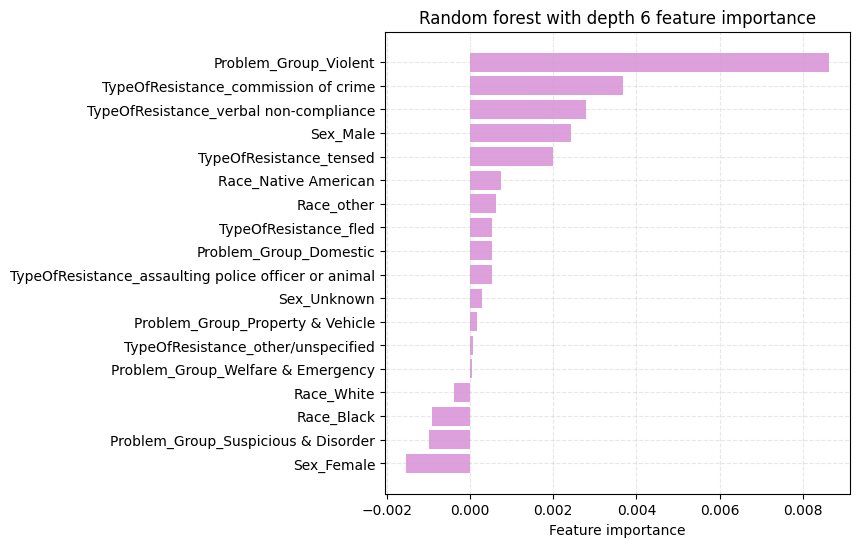

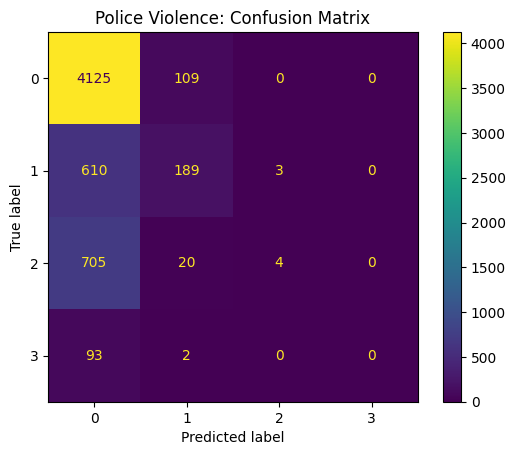

accuracy: 0.7368600682593857
              precision    recall  f1-score   support

           1     0.7455    0.9743    0.8447      4234
           2     0.5906    0.2357    0.3369       802
           3     0.5714    0.0055    0.0109       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7369      5860
   macro avg     0.4769    0.3039    0.2981      5860
weighted avg     0.6906    0.7369    0.6578      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

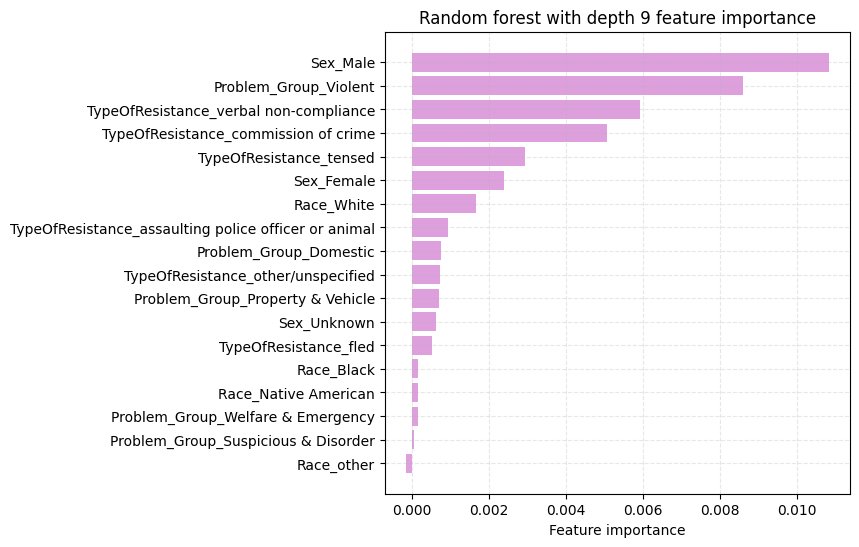

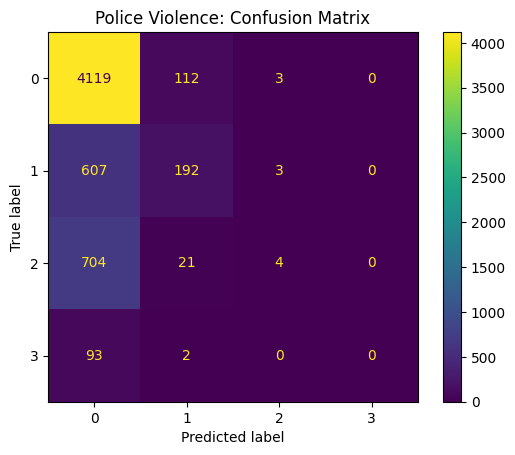

accuracy: 0.7363481228668942
              precision    recall  f1-score   support

           1     0.7458    0.9728    0.8443      4234
           2     0.5872    0.2394    0.3401       802
           3     0.4000    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7363      5860
   macro avg     0.4332    0.3044    0.2988      5860
weighted avg     0.6690    0.7363    0.6579      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

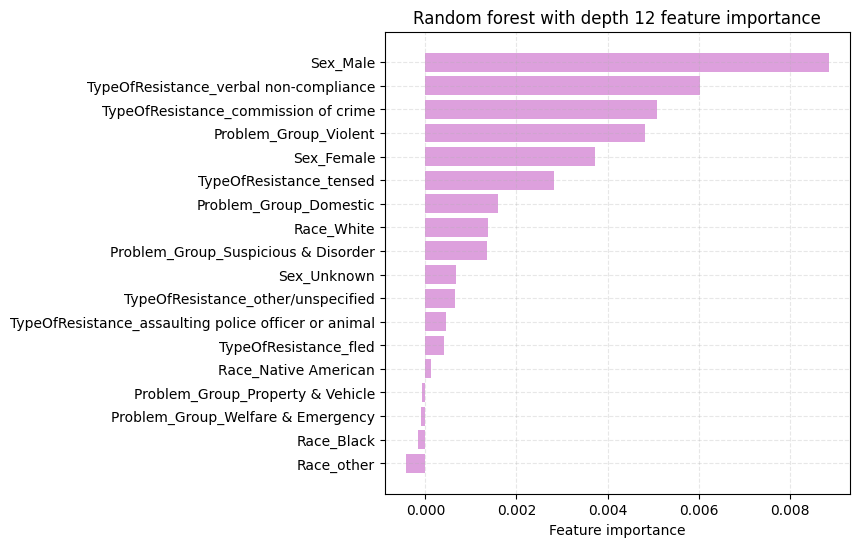

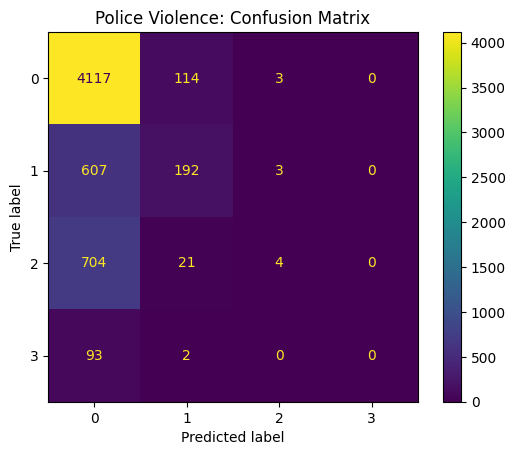

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7457    0.9724    0.8441      4234
           2     0.5836    0.2394    0.3395       802
           3     0.4000    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4323    0.3043    0.2986      5860
weighted avg     0.6684    0.7360    0.6577      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

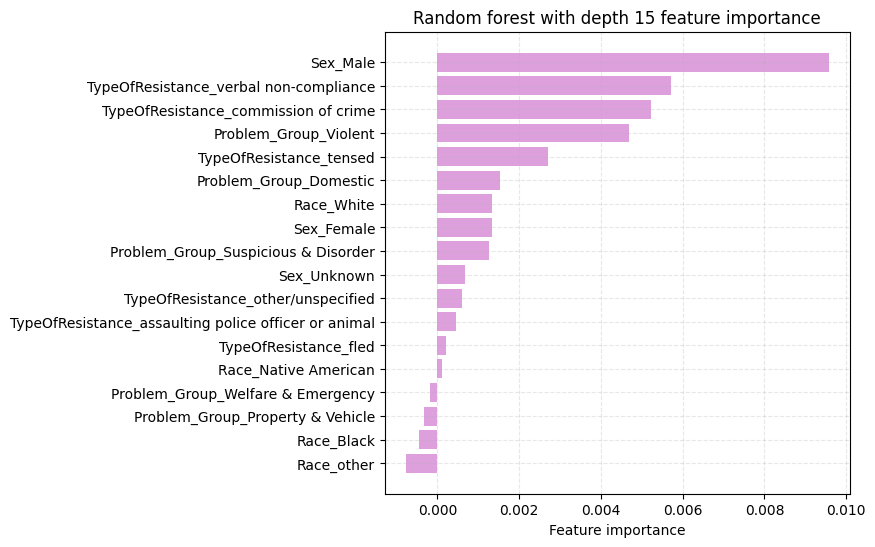

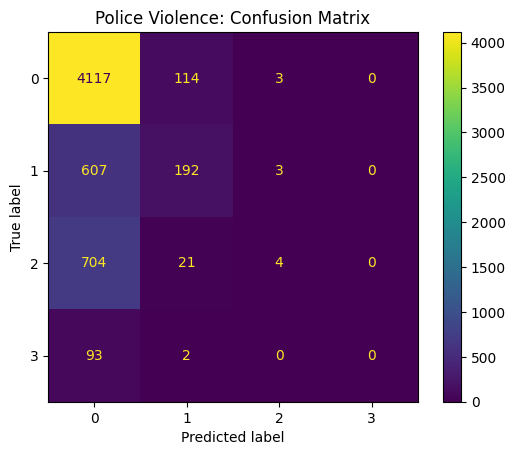

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7457    0.9724    0.8441      4234
           2     0.5836    0.2394    0.3395       802
           3     0.4000    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4323    0.3043    0.2986      5860
weighted avg     0.6684    0.7360    0.6577      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

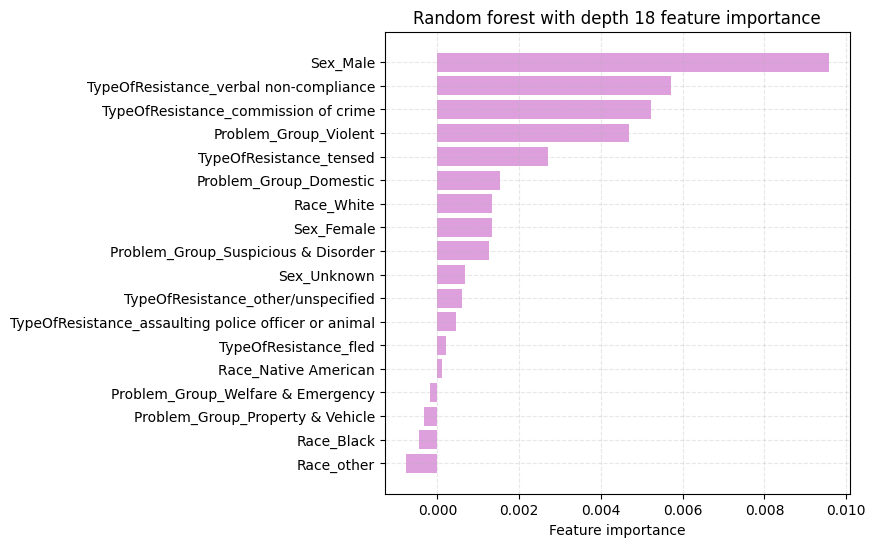

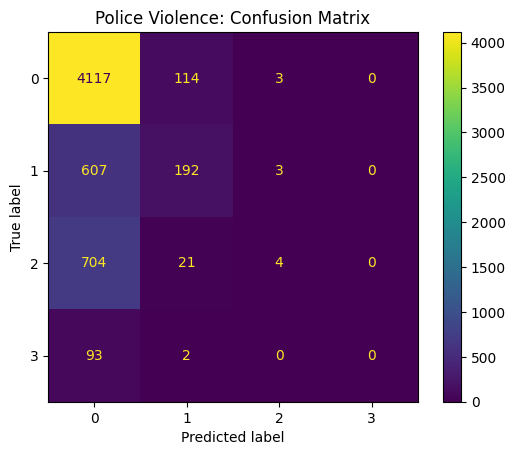

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7457    0.9724    0.8441      4234
           2     0.5836    0.2394    0.3395       802
           3     0.4000    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4323    0.3043    0.2986      5860
weighted avg     0.6684    0.7360    0.6577      5860

None


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

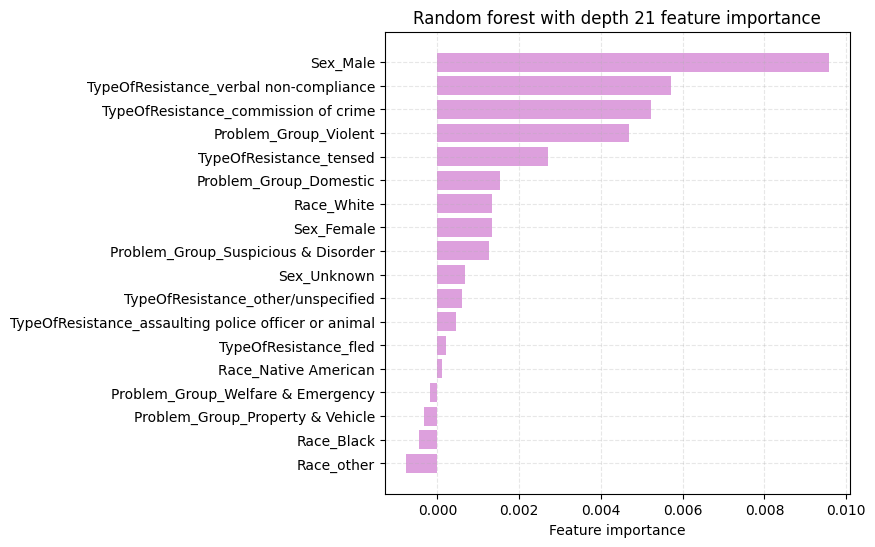

In [283]:
# training the random forest model on the training set
# and printing out its performance metrics
p = X_train.shape[1]    # the number of features
print(p)

for i in range(3,22,3):
    rf = RandomForestClassifier(
        n_estimators=500,  # this means there will be 500 trees in the forest
        max_features= math.floor(math.sqrt(p)),
        max_depth=i,    
        random_state=0
    )
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    metrics = eval_tree(y_test, y_pred)

    print(metrics)

    names = X_train.columns.tolist()
    result = permutation_importance(
        rf, X_test, y_test, n_repeats=10, random_state=42
    )

    # You can then access the mean importance scores via result.importances_mean
    perm_importances = pd.Series(result.importances_mean, index=names).sort_values()

    plt.figure(figsize=(6,6))
    plt.barh(perm_importances.index, perm_importances.values, color="plum")
    plt.xlabel("Feature importance")
    plt.title(f"Random forest with depth {i} feature importance")
    add_grid()
    plt.show()

max_depth 9 is the best for the random forest, so I will use that in the partial dependence plots. This again confirms that the single trees are not overfitting, though, since the accuracy is around the same for the random forests and the bagged trees as the single decision trees. 

In [284]:
rf_9 = RandomForestClassifier(
        n_estimators=500,  # this means there will be 500 trees in the forest
        max_features= math.floor(math.sqrt(p)),
        max_depth=9,    
        random_state=0
    )
rf_9.fit(X_train, y_train)
y_pred = rf.predict(X_test)

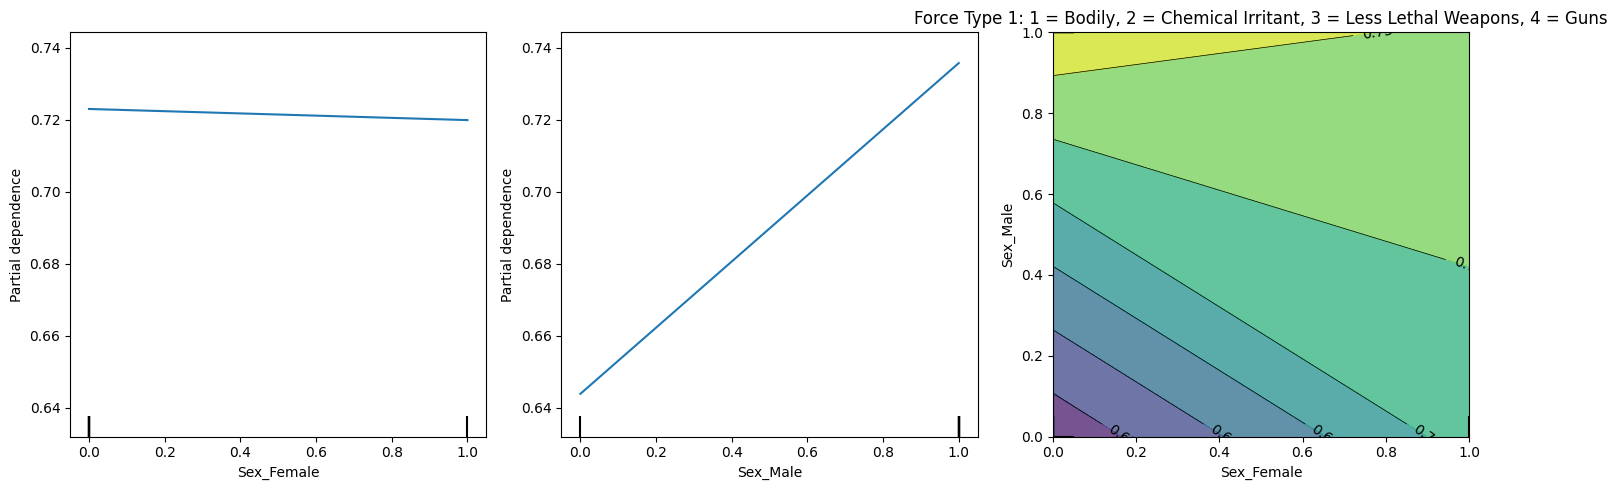

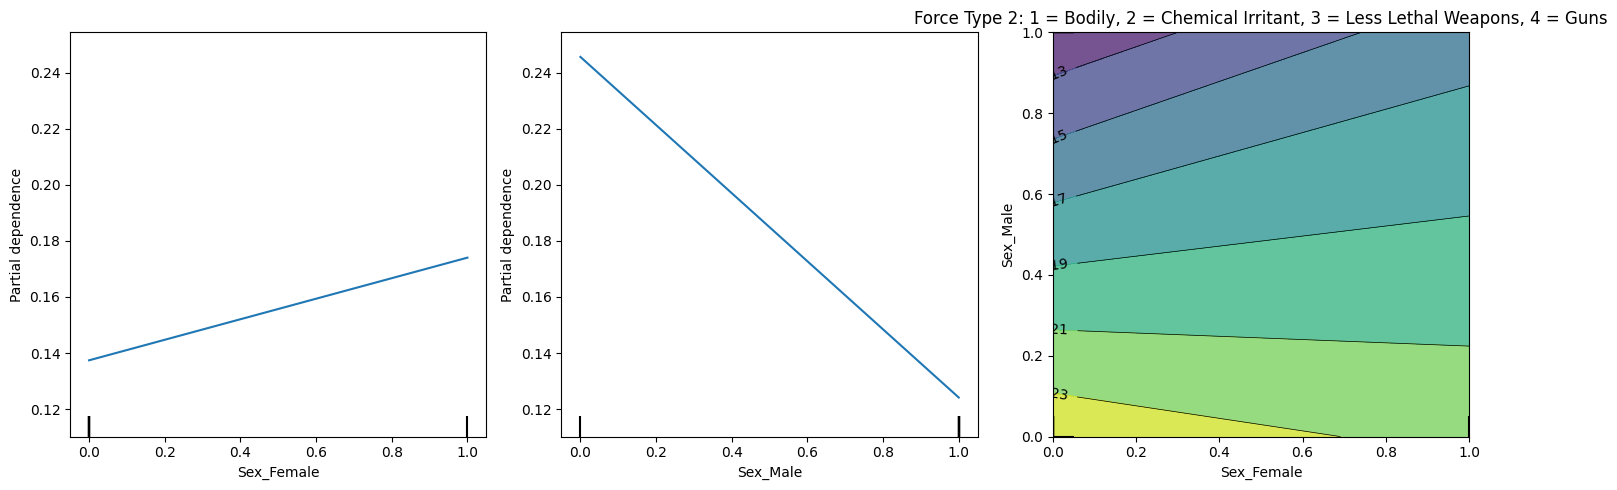

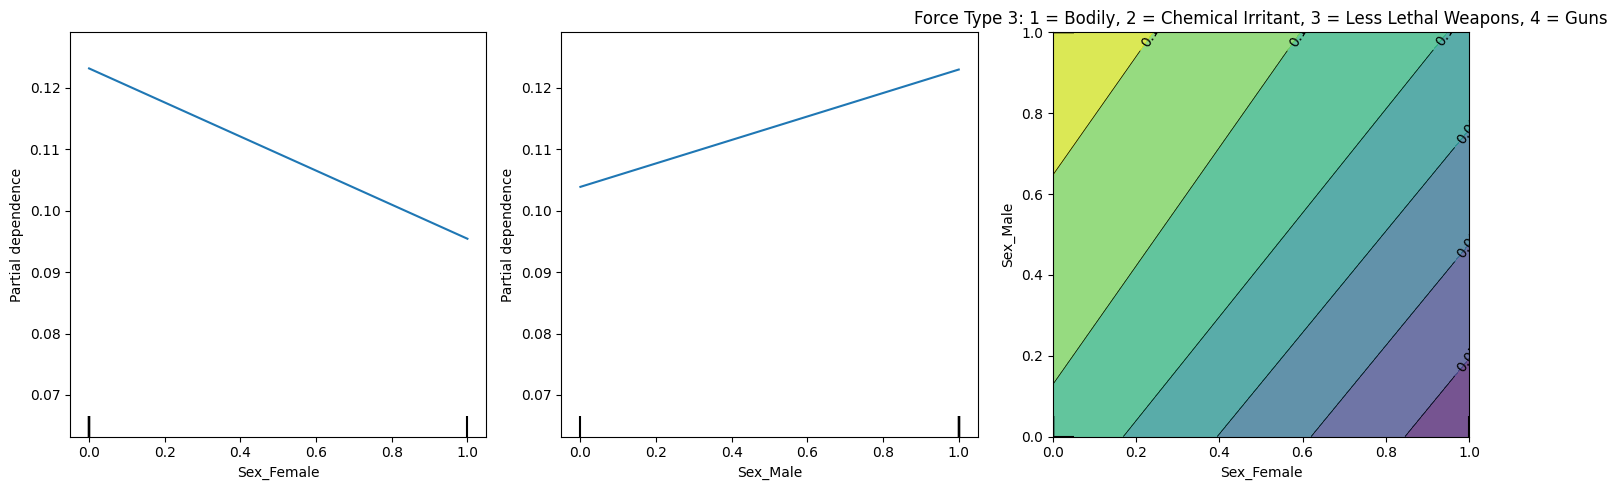

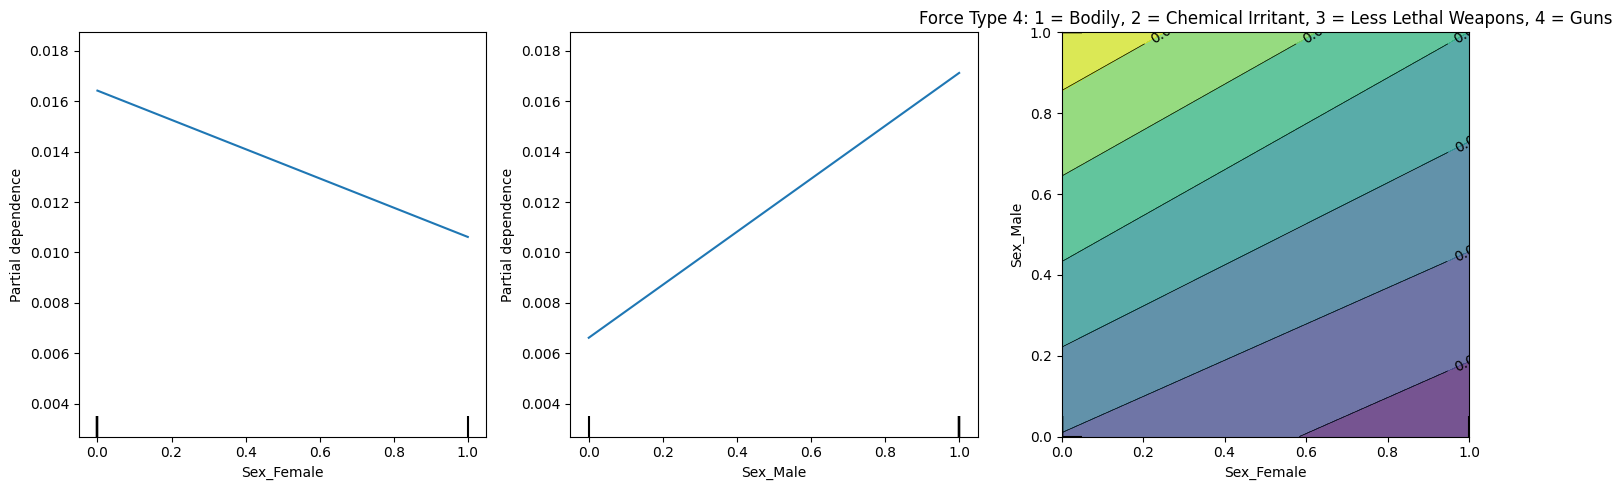

In [285]:
for i in [1,2,3,4]:
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

    # calling the best random forrest model
    display = PartialDependenceDisplay.from_estimator(
        rf_9, 
        X_encoded, 
        features=[0, 1, (0, 1)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.tight_layout()
    plt.show()

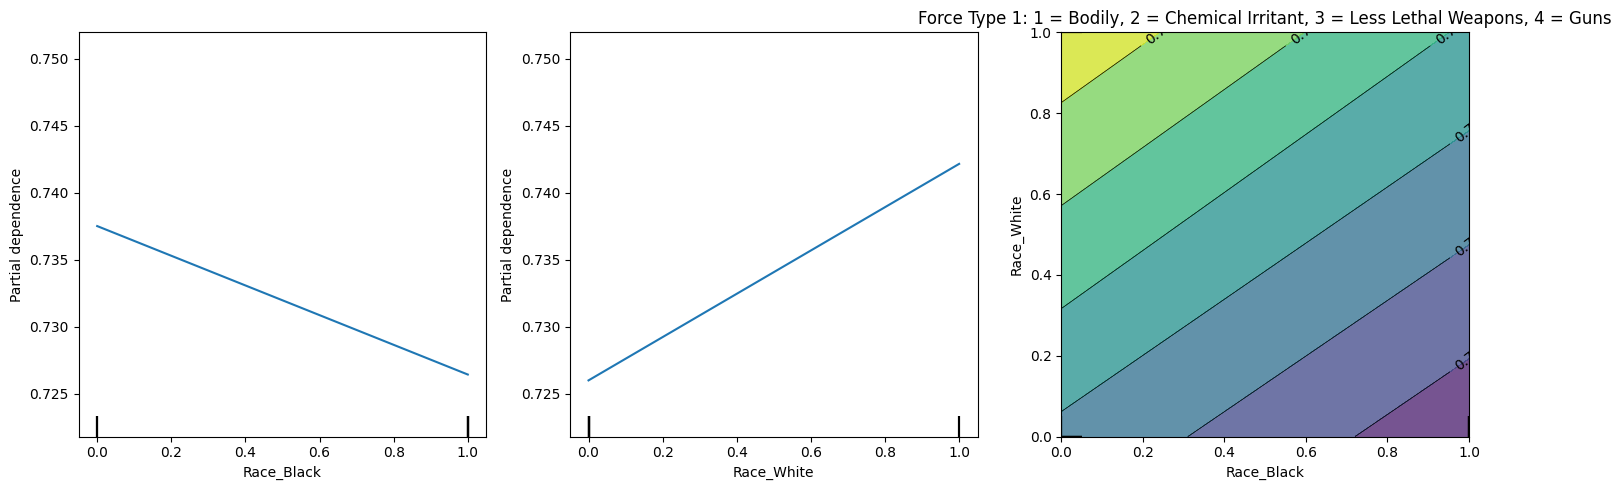

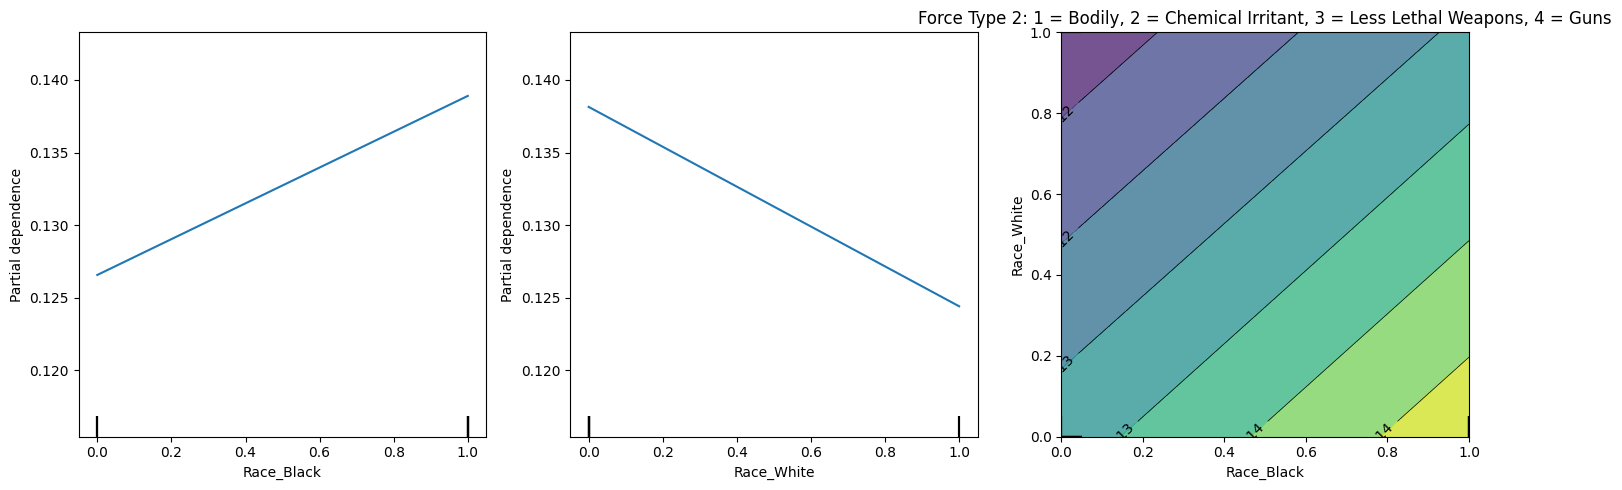

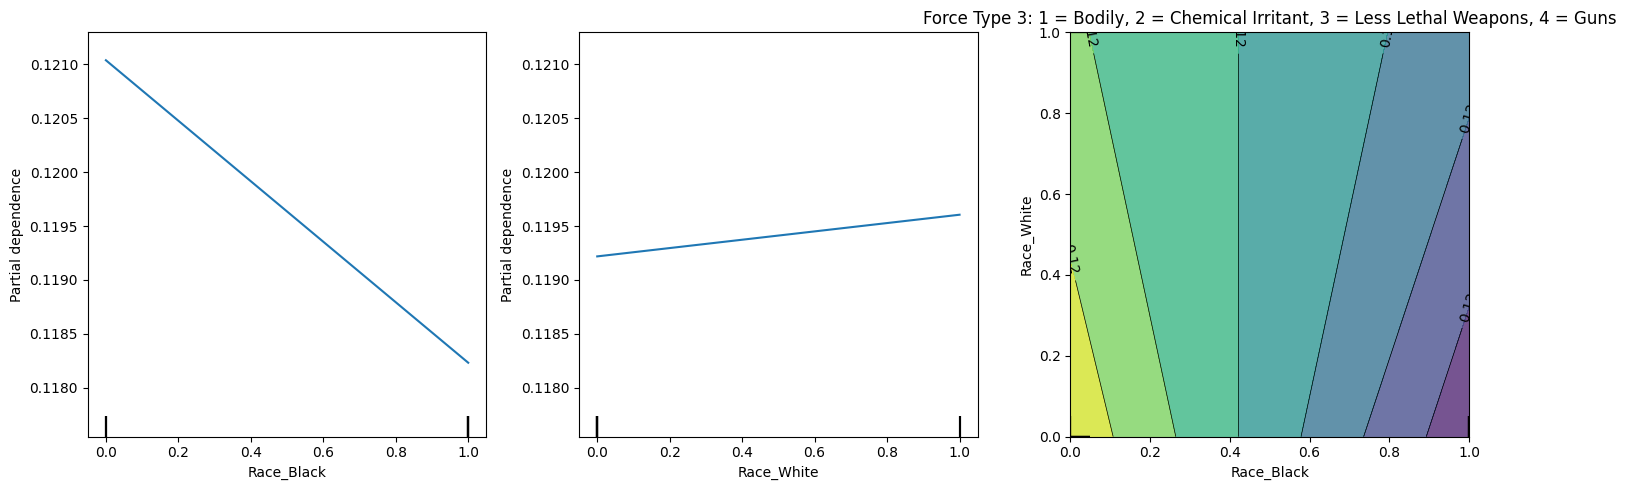

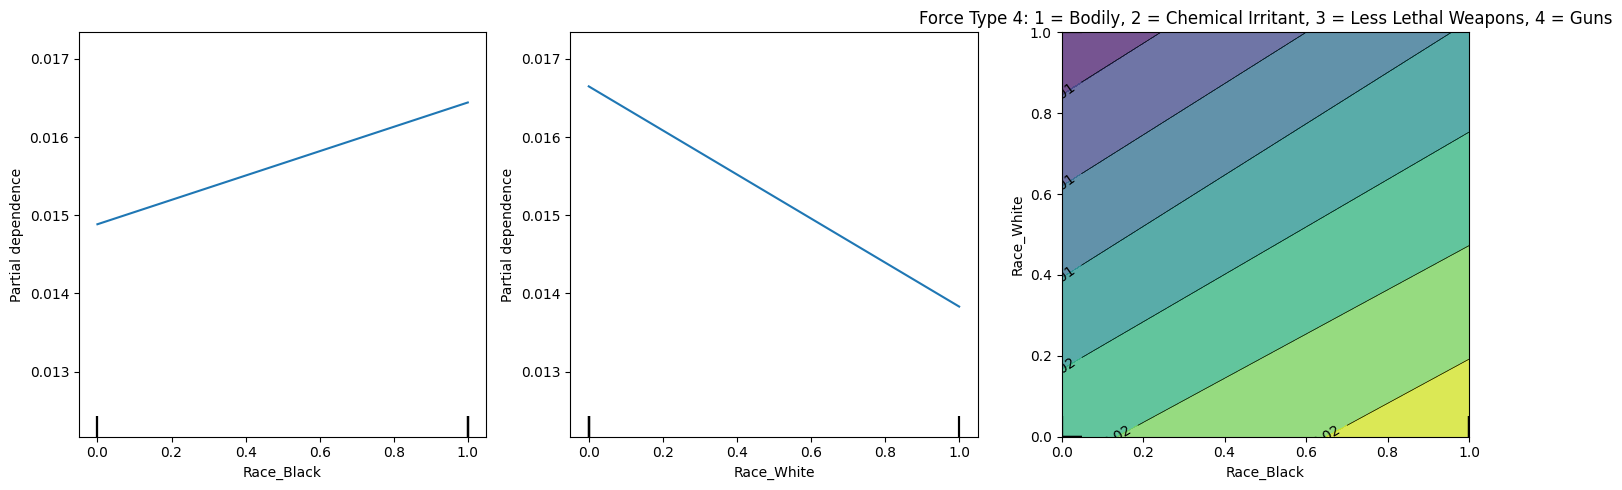

In [286]:
for i in [1,2,3,4]:
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

    # calling the best random forrest model
    display = PartialDependenceDisplay.from_estimator(
        rf_9, 
        X_encoded, 
        features=[3, 5, (3, 5)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.tight_layout()
    plt.show()

Even with class imbalance, these plots are showing a similar story as the boosted model's plots.

In [316]:
# Finally, trying a forest model and feature importance with classes balanced 
df = pd.read_csv('final_data.csv')
df = df.drop(columns = ['Unnamed: 0', 'CenterLatitude', 'CenterLongitude'])
print(df.head())

df1 = df[df['ForceType'] == 'Bodily Force'].sample(n=466)
df2 = df[df['ForceType'] == 'Less Lethal Weapons'].sample(n=466)
df3 = df[df['ForceType'] == 'Chemical Irritant'].sample(n=466)
df4 = df[df['ForceType'] == 'Guns']
final = pd.concat([df1, df2, df3, df4], ignore_index=True)

final.shape

             ForceType     Sex   Race       TypeOfResistance  \
0         Bodily Force  Female  Black                 tensed   
1         Bodily Force    Male  Black                   fled   
2         Bodily Force    Male  Black  verbal non-compliance   
3  Less Lethal Weapons    Male  White                 tensed   
4         Bodily Force    Male  White  verbal non-compliance   

           Problem_Group  
0                Violent  
1  Suspicious & Disorder  
2  Suspicious & Disorder  
3    Welfare & Emergency  
4                Violent  


(1864, 5)

In [317]:
final['ForceType'] = final['ForceType'].replace('Bodily Force', 1)
final['ForceType'] = final['ForceType'].replace('Chemical Irritant', 2)
final['ForceType'] = final['ForceType'].replace('Less Lethal Weapons', 3)
final['ForceType'] = final['ForceType'].replace('Guns', 4)
X = final.drop(columns = ['ForceType'])
y = final['ForceType']

# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)
X_train.head()

/var/folders/4s/n0fx9vd51tq800lszw3bs_400000gn/T/ipykernel_26336/814137090.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final['ForceType'] = final['ForceType'].replace('Guns', 4)


,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
177,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1762,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1279,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
1189,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
1088,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1


In [318]:
rf_9 = RandomForestClassifier(
        n_estimators=500,  # this means there will be 500 trees in the forest
        max_features= math.floor(math.sqrt(p)),
        max_depth=9,    
        random_state=0
    )
rf_9.fit(X_train, y_train)
y_pred = rf.predict(X_test)

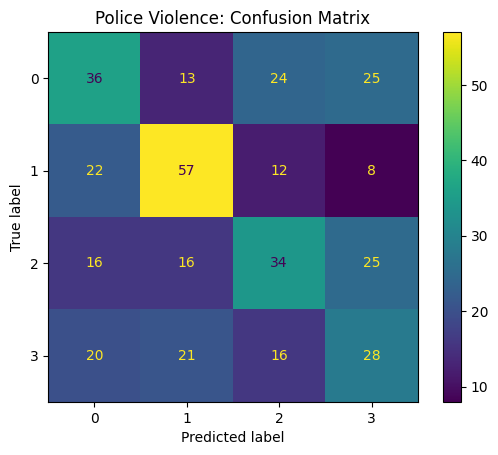

accuracy: 0.4155495978552279
              precision    recall  f1-score   support

           1     0.3830    0.3673    0.3750        98
           2     0.5327    0.5758    0.5534        99
           3     0.3953    0.3736    0.3842        91
           4     0.3256    0.3294    0.3275        85

    accuracy                         0.4155       373
   macro avg     0.4092    0.4115    0.4100       373
weighted avg     0.4127    0.4155    0.4138       373

None


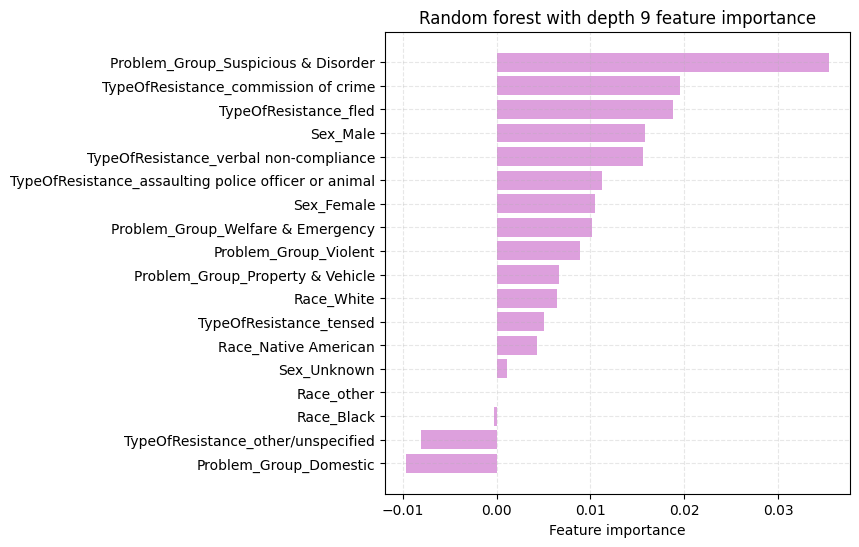

In [319]:
# feature importance and confusion matrix

y_pred = rf_9.predict(X_test)

metrics = eval_tree(y_test, y_pred)
print(metrics)

names = X_train.columns.tolist()
result = permutation_importance(
    rf_9, X_test, y_test, n_repeats=10, random_state=42
)

# You can then access the mean importance scores via result.importances_mean
perm_importances = pd.Series(result.importances_mean, index=names).sort_values()

plt.figure(figsize=(6,6))
plt.barh(perm_importances.index, perm_importances.values, color="plum")
plt.xlabel("Feature importance")
plt.title(f"Random forest with depth 9 feature importance")
add_grid()
plt.show()

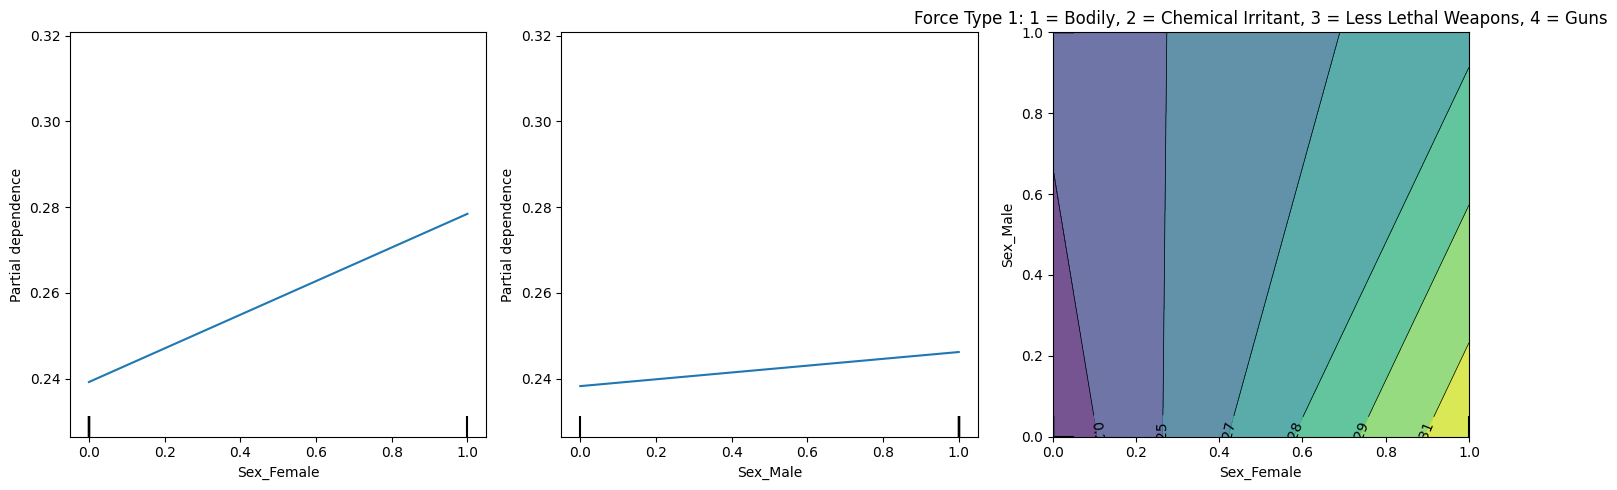

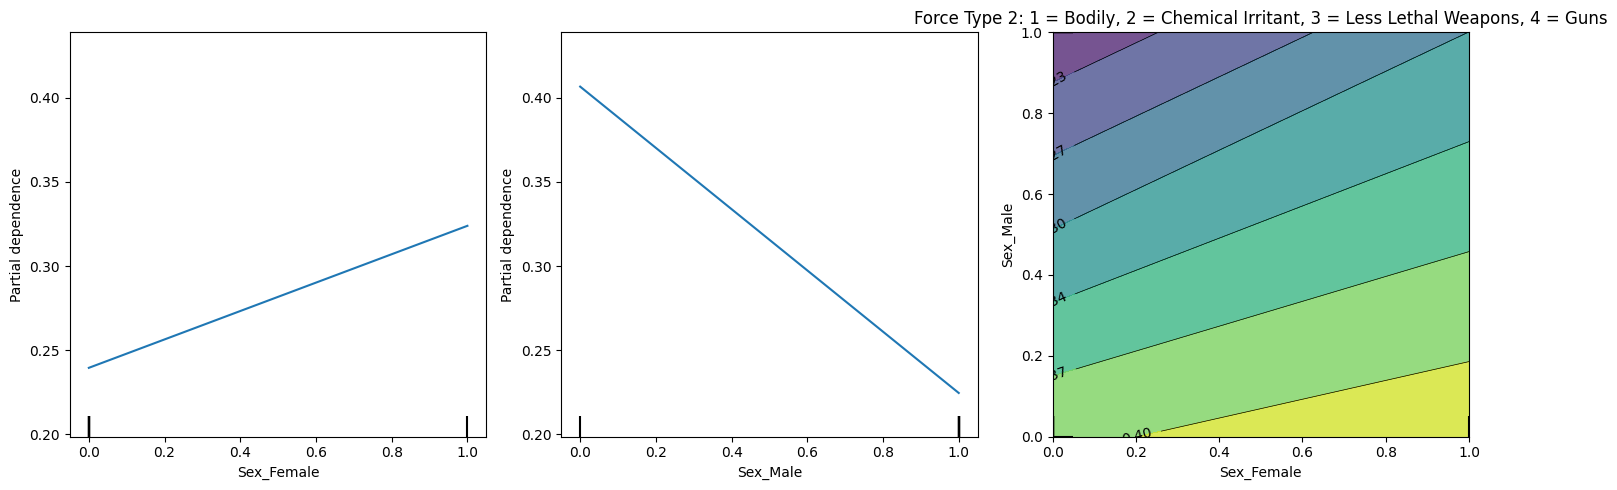

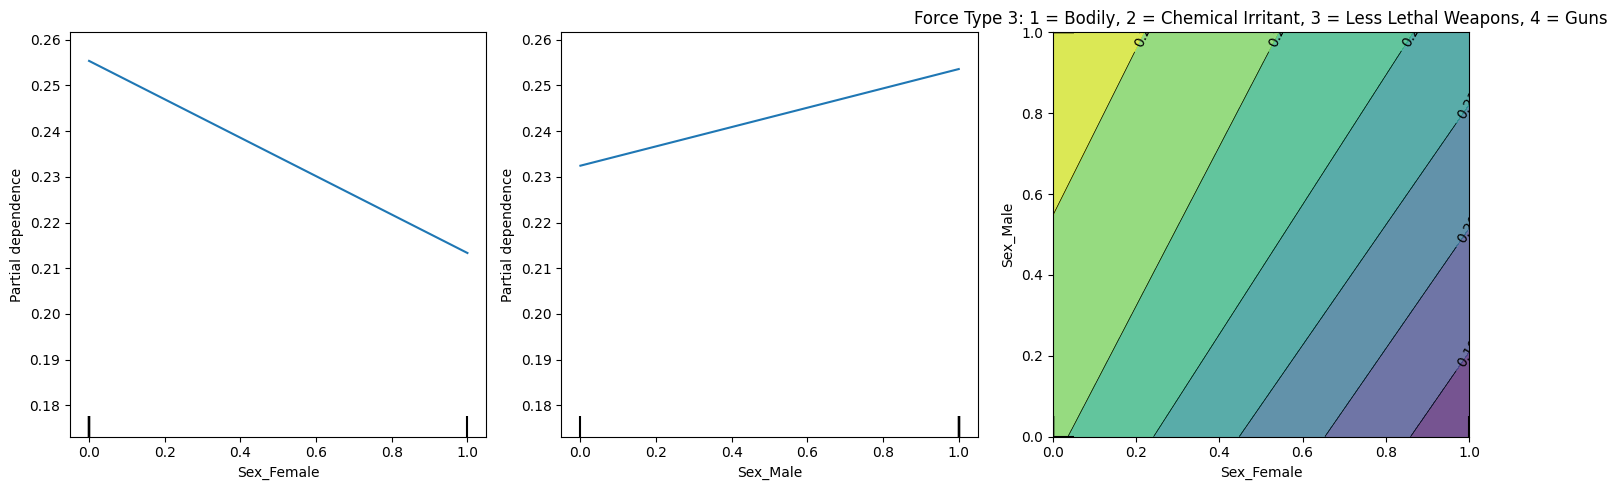

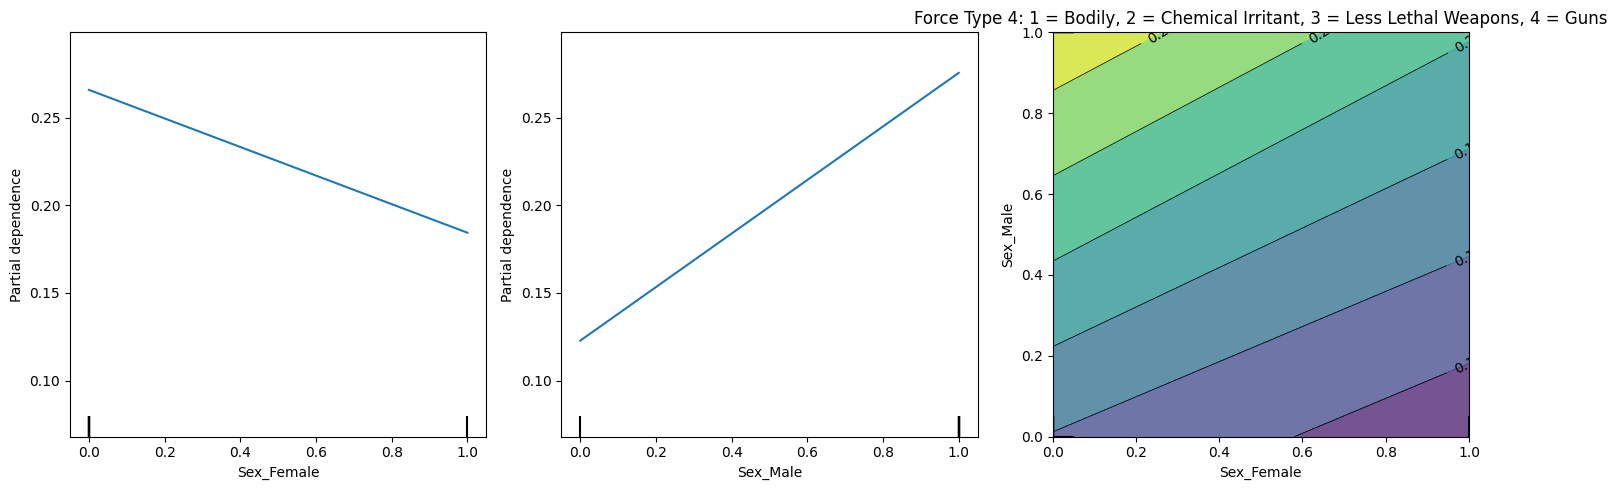

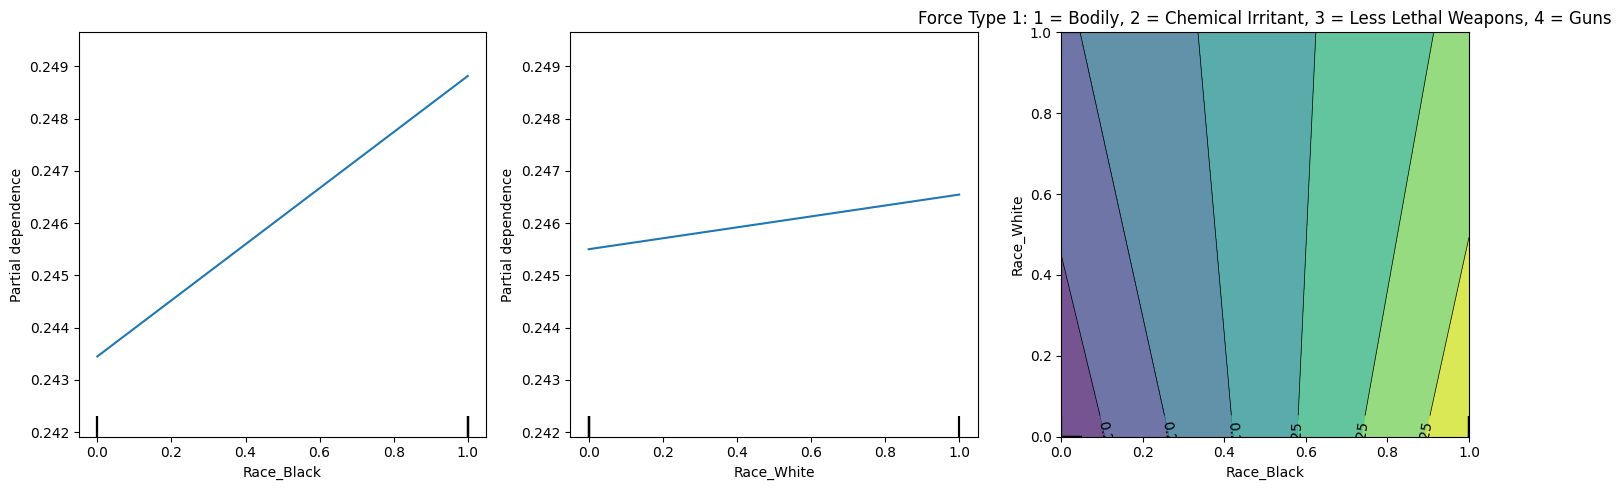

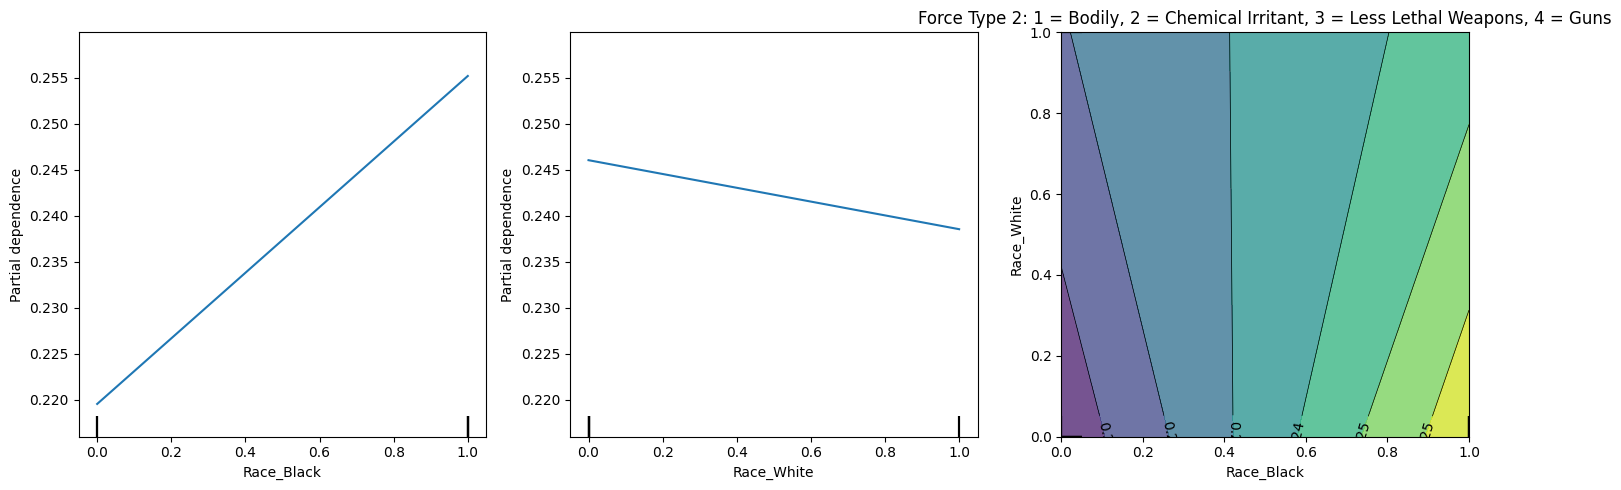

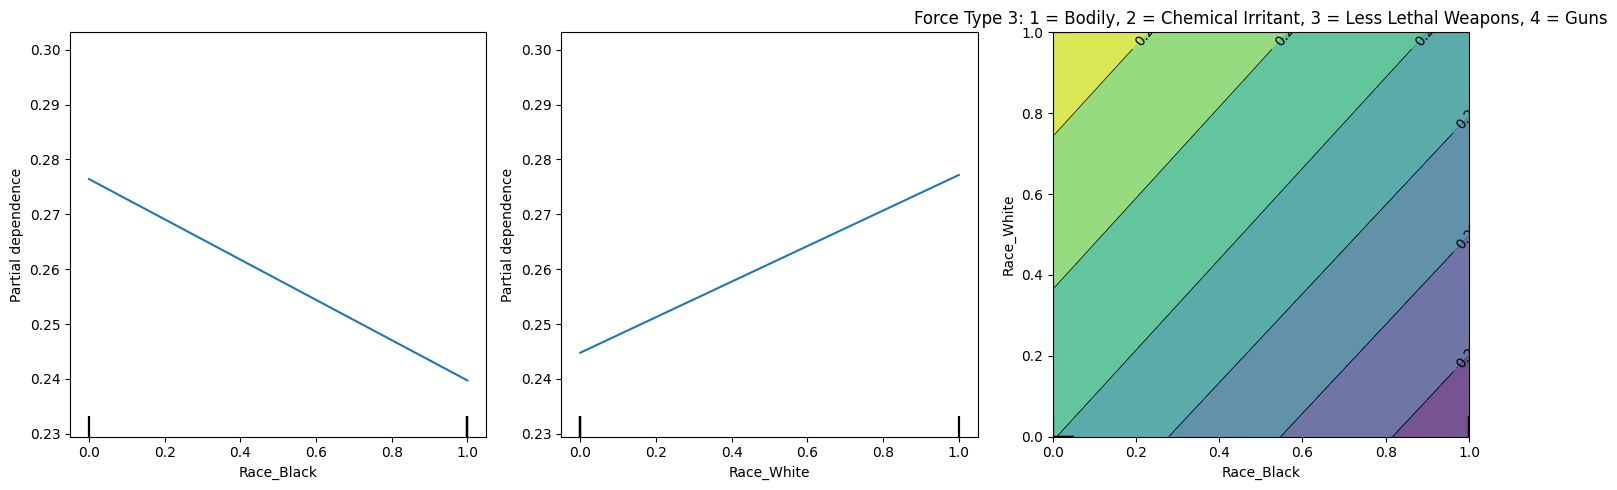

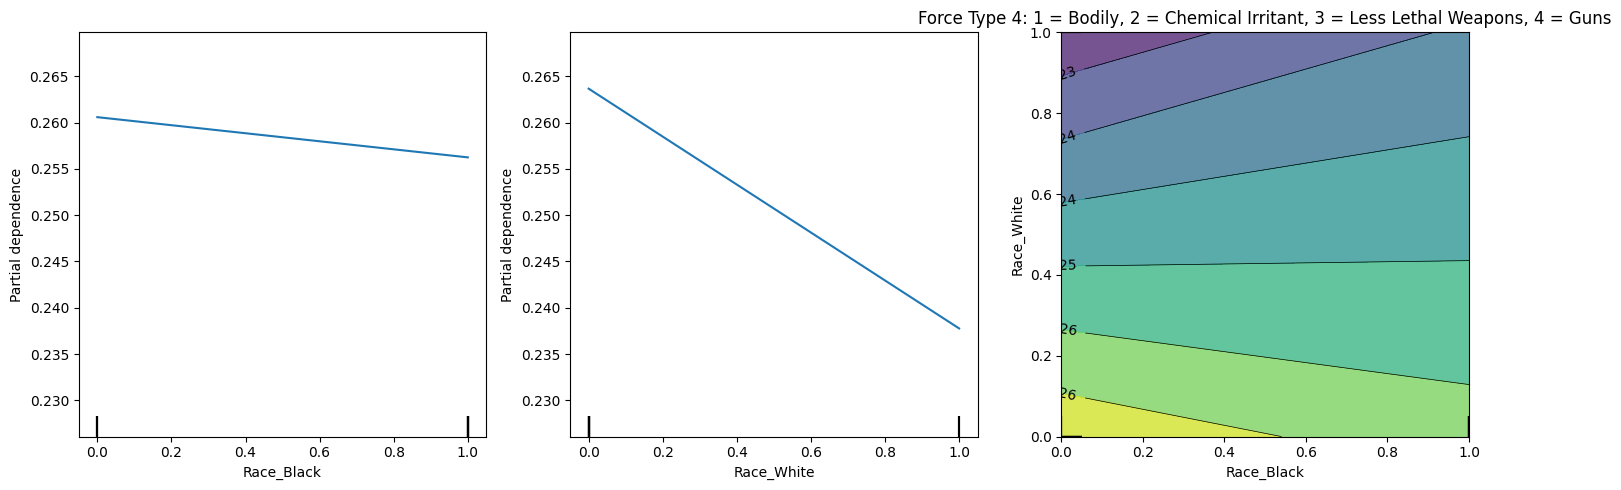

In [320]:
for i in [1,2,3,4]:
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

    # calling the best random forrest model
    display = PartialDependenceDisplay.from_estimator(
        rf_9, 
        X_encoded, 
        features=[0, 1, (0, 1)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.tight_layout()
    plt.show()

for i in [1,2,3,4]:
    # creating the figure so it will make 3 plots
    fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

    # calling the best random forrest model
    display = PartialDependenceDisplay.from_estimator(
        rf_9, 
        X_encoded, 
        features=[3, 5, (3, 5)], 
        feature_names=names,
        target=i, # Guns class
        ax=ax     
    )

    plt.title(f'Force Type {i}: 1 = Bodily, 2 = Chemical Irritant, 3 = Less Lethal Weapons, 4 = Guns')
    plt.tight_layout()
    plt.show()

## Bagging!

In [321]:
# it kept creating new target categories, so for this once encoding the target to be numbers
# Bodily Force           21548
# Chemical Irritant       4125
# Less Lethal Weapons     3565
# Guns                     478
df_final['ForceType'] = df_final['ForceType'].replace('Bodily Force', 1)
df_final['ForceType'] = df_final['ForceType'].replace('Chemical Irritant', 2)
df_final['ForceType'] = df_final['ForceType'].replace('Less Lethal Weapons', 3)
df_final['ForceType'] = df_final['ForceType'].replace('Guns', 4)
print(df_final['ForceType'].value_counts())

X = df_final.drop(columns = ['ForceType', 'Unnamed: 0', 'CenterLongitude', 'CenterLatitude'])
y = df_final['ForceType']

# we have to encode the columns for the tree to work
# using onehot encoder for the variables that have fewer categories
X_encoded = pd.get_dummies(X, columns= ['Sex', 'Race', 'TypeOfResistance', 'Problem_Group'], drop_first=False, dtype=int)

# splitting into training and testing - single fold cross validation
# we will try k-fold cross validation after this
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)
X_train.head()

ForceType
1    21343
2     3970
3     3517
4      466
Name: count, dtype: int64


,Sex_Female,Sex_Male,Sex_Unknown,Race_Black,Race_Native American,Race_White,Race_other,TypeOfResistance_assaulting police officer or animal,TypeOfResistance_commission of crime,TypeOfResistance_fled,TypeOfResistance_other/unspecified,TypeOfResistance_tensed,TypeOfResistance_verbal non-compliance,Problem_Group_Domestic,Problem_Group_Property & Vehicle,Problem_Group_Suspicious & Disorder,Problem_Group_Violent,Problem_Group_Welfare & Emergency
7193,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
15903,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
14323,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
21947,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0
11094,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0


In [322]:
# function to get the mode of categorical target encoded as ints 1-4
np.random.seed(17)
def get_random_mode(arr):
    values, counts = np.unique(arr, return_counts=True)
    max_count = np.max(counts)
    winners = values[counts == max_count]
    
    return np.random.choice(winners)

# writing my own bagging function
def tree_bagging(X_train, y_train, X_test, B, max_depth):
    '''This function will bootstrap B data sets from X_train and y_train data 
    and fit a classification tree using DecisionTreeClassifier to each one at the
    specified max_depth, then generates predictions for each observation
    in the X_test by choosing majority vote of their predictions across the boostrap models'''
    np.random.seed(0)
    n = len(X_train)

    #this is going to be a list of all arrays returned by the tree's prediction
    all_predictions = []
    
    # first creating the bootstrap samples
    for i in range(B):
        bootstrap_indices = np.random.choice(a=n, size=n, replace=True)
        bootstrap_sample = X_train.iloc[bootstrap_indices]
        bootstrap_y = y_train.iloc[bootstrap_indices]

        # for each sample, fitting a model to the training data
        tree = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        tree.fit(bootstrap_sample, bootstrap_y)

        # calculating this tree's predictions on the test set
        predictions = tree.predict(X_test)
        all_predictions.append(predictions)
    
    # using majority vote for the final predictions
    stacked_predictions = np.vstack(all_predictions)
    stacked_predictions = stacked_predictions.astype(int)
    
    # calculate the mode along the vertical axis (axis=0)
    bagged_test_preds = np.apply_along_axis(get_random_mode, axis=0, arr=stacked_predictions)
    
    return bagged_test_preds

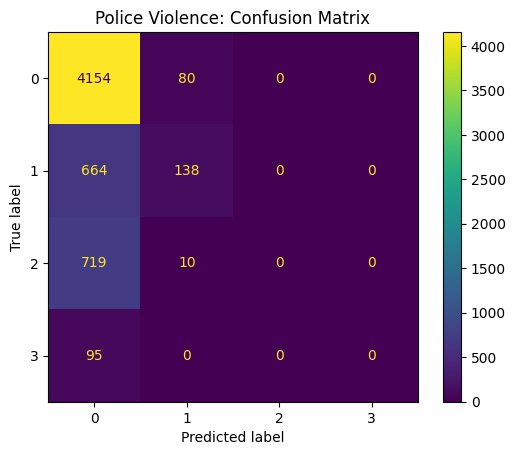

accuracy: 0.7324232081911263
              precision    recall  f1-score   support

           1     0.7376    0.9811    0.8421      4234
           2     0.6053    0.1721    0.2680       802
           3     0.0000    0.0000    0.0000       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7324      5860
   macro avg     0.3357    0.2883    0.2775      5860
weighted avg     0.6158    0.7324    0.6451      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

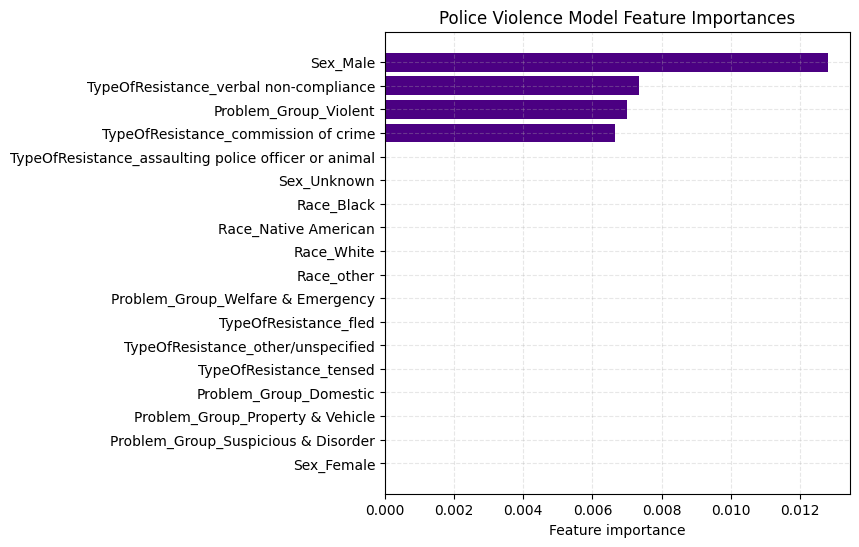

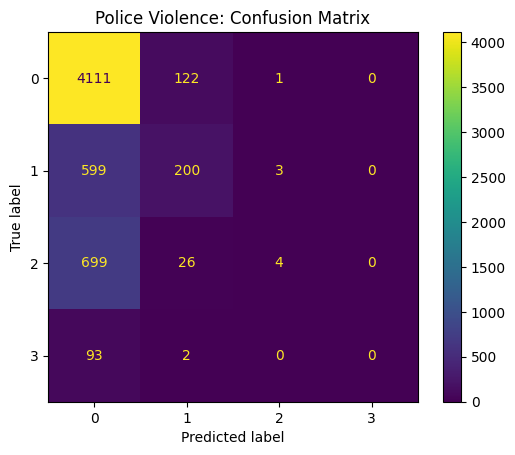

accuracy: 0.7363481228668942
              precision    recall  f1-score   support

           1     0.7472    0.9709    0.8445      4234
           2     0.5714    0.2494    0.3472       802
           3     0.5000    0.0055    0.0109       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7363      5860
   macro avg     0.4547    0.3065    0.3006      5860
weighted avg     0.6803    0.7363    0.6590      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

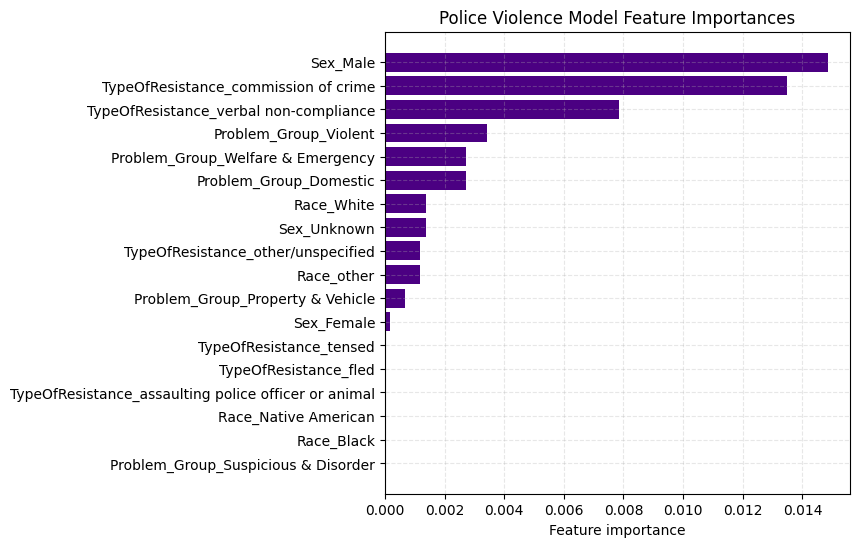

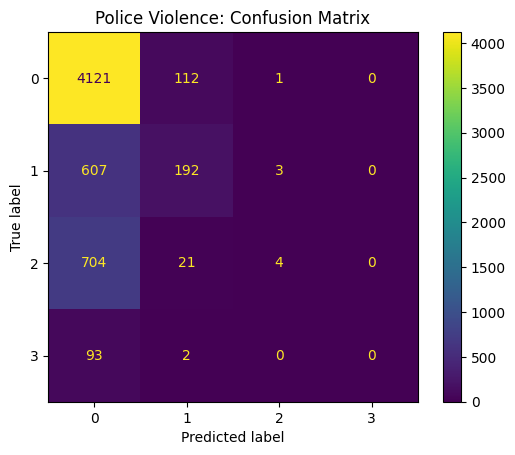

accuracy: 0.7366894197952218
              precision    recall  f1-score   support

           1     0.7459    0.9733    0.8446      4234
           2     0.5872    0.2394    0.3401       802
           3     0.5000    0.0055    0.0109       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7367      5860
   macro avg     0.4583    0.3045    0.2989      5860
weighted avg     0.6815    0.7367    0.6581      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

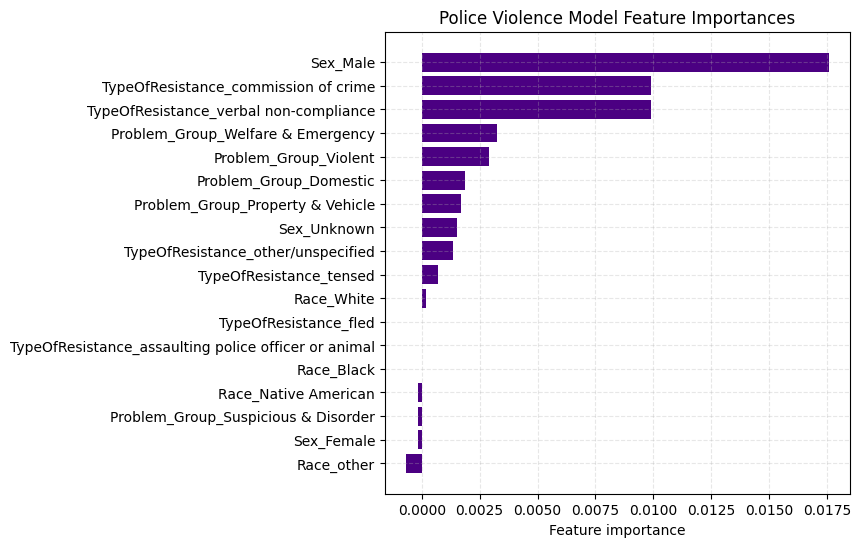

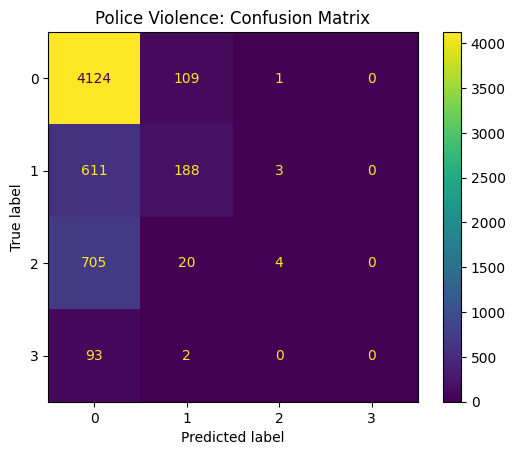

accuracy: 0.736518771331058
              precision    recall  f1-score   support

           1     0.7453    0.9740    0.8445      4234
           2     0.5893    0.2344    0.3354       802
           3     0.5000    0.0055    0.0109       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7365      5860
   macro avg     0.4587    0.3035    0.2977      5860
weighted avg     0.6814    0.7365    0.6574      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

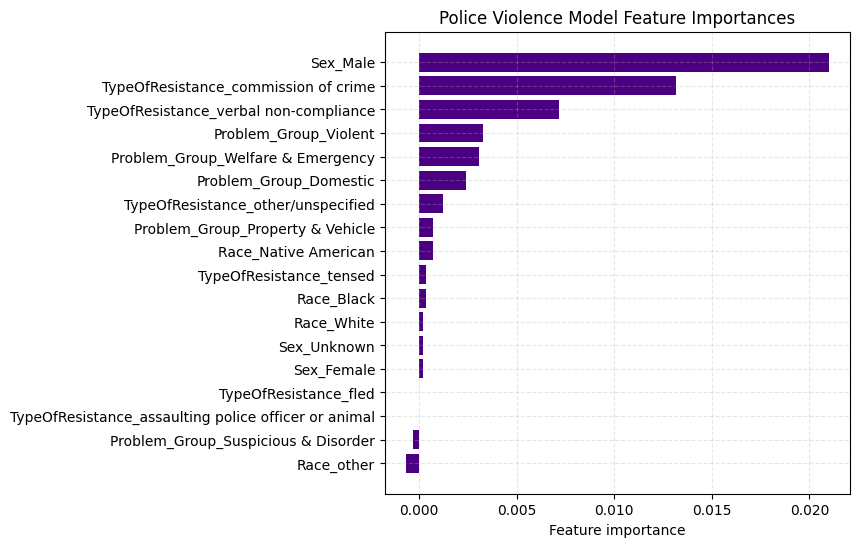

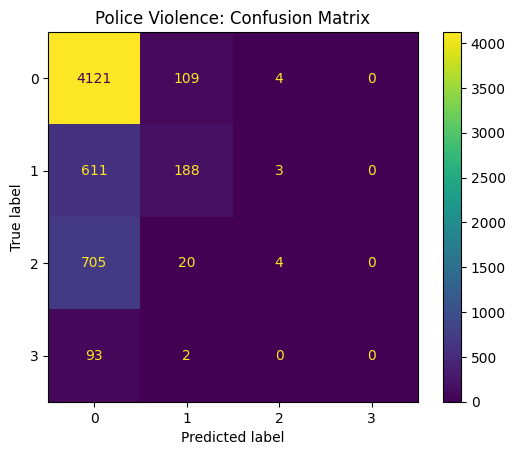

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7452    0.9733    0.8441      4234
           2     0.5893    0.2344    0.3354       802
           3     0.3636    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4245    0.3033    0.2976      5860
weighted avg     0.6643    0.7360    0.6571      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

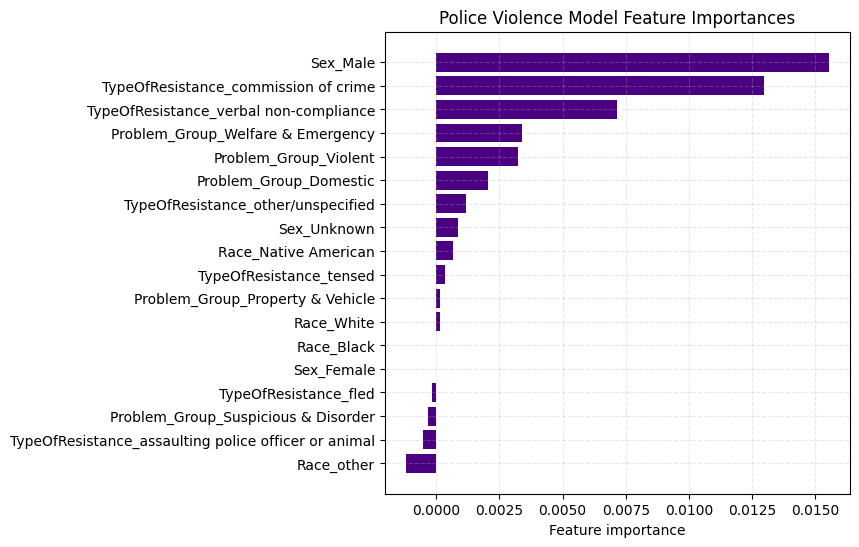

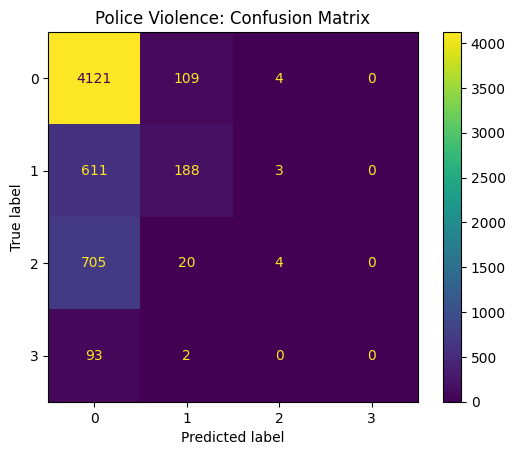

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7452    0.9733    0.8441      4234
           2     0.5893    0.2344    0.3354       802
           3     0.3636    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4245    0.3033    0.2976      5860
weighted avg     0.6643    0.7360    0.6571      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

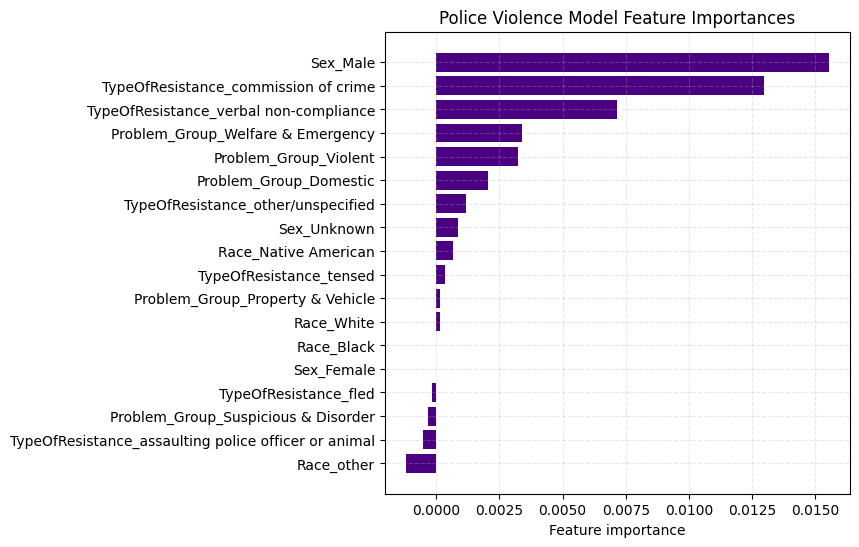

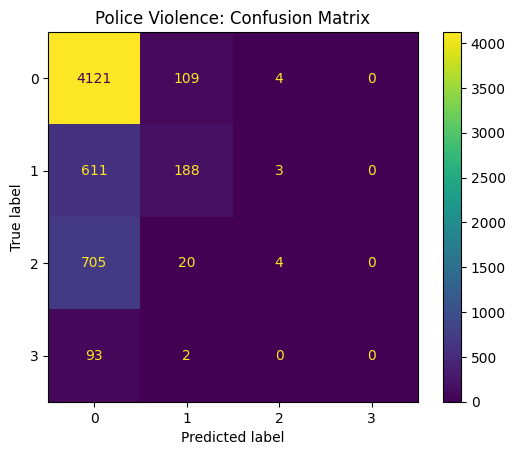

accuracy: 0.7360068259385666
              precision    recall  f1-score   support

           1     0.7452    0.9733    0.8441      4234
           2     0.5893    0.2344    0.3354       802
           3     0.3636    0.0055    0.0108       729
           4     0.0000    0.0000    0.0000        95

    accuracy                         0.7360      5860
   macro avg     0.4245    0.3033    0.2976      5860
weighted avg     0.6643    0.7360    0.6571      5860



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

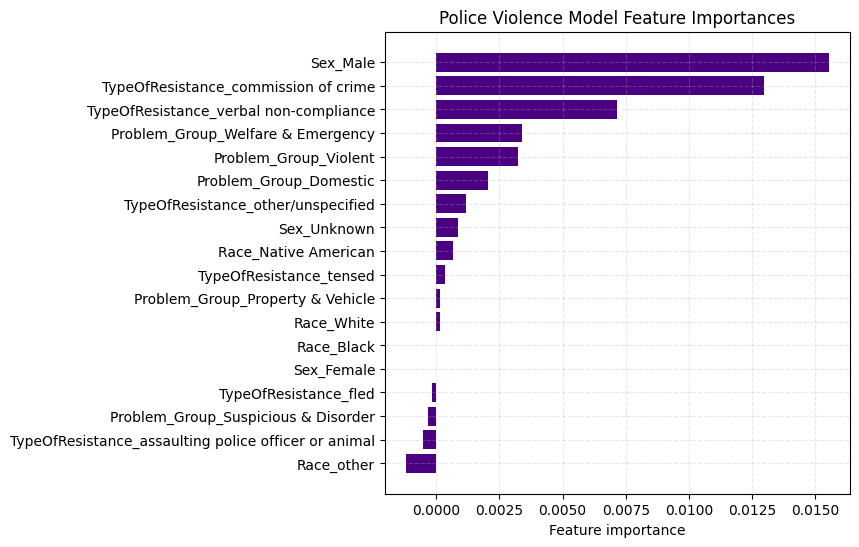

In [323]:
# arbitrarily choosing to make 50 bootstrap samples
for i in range(3,22,3):
    bag_predictions = tree_bagging(X_train, y_train, X_test, 50, i)
    eval_tree(y_test, bag_predictions)

    # visualize the feature importances (which features led to the largest reduction in loss)
    names = X_train.columns.tolist()
    baseline_acc = accuracy_score(y_test, bag_predictions)
    importances = []

    for col in names:
        # copy the X_test data and shuffle it to calculate permutation importance manually
        X_test_shuffled = X_test.copy()
        X_test_shuffled[col] = np.random.permutation(X_test_shuffled[col].values)
        
        # using the hand-coded bagging algorithm to predict the shuffled test set
        shuffled_preds = tree_bagging(X_train, y_train, X_test_shuffled, 50, i)
        
        # finding the drop in performace from the shuffled data
        shuffled_acc = accuracy_score(y_test, shuffled_preds)
        importances.append(baseline_acc - shuffled_acc)

        # repeating for each column to see which shuffle makes performance drop the most

    importance_series = pd.Series(importances, index=names).sort_values()
    plt.figure(figsize=(6,6))
    plt.barh(importance_series.index, importance_series.values, color = 'indigo')
    plt.xlabel("Feature importance")
    plt.title("Police Violence Model Feature Importances")
    add_grid()
    plt.show()